### Importing necessary libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
plt.style.use("default")
sns.set(font_scale=1.1)

## Reading Dataset

In [3]:
df = pd.read_csv('diabetes_dataset.csv')
df.head(10)

,age,gender,ethnicity,education_level,income_level,employment_status,smoking_status,alcohol_consumption_per_week,physical_activity_minutes_per_week,diet_score,...,hdl_cholesterol,ldl_cholesterol,triglycerides,glucose_fasting,glucose_postprandial,insulin_level,hba1c,diabetes_risk_score,diabetes_stage,diagnosed_diabetes
0,58,Male,Asian,Highschool,Lower-Middle,Employed,Never,0,215,5.7,...,41,160,145,136,236,6.36,8.18,29.6,Type 2,1
1,48,Female,White,Highschool,Middle,Employed,Former,1,143,6.7,...,55,50,30,93,150,2.00,5.63,23.0,No Diabetes,0
2,60,Male,Hispanic,Highschool,Middle,Unemployed,Never,1,57,6.4,...,66,99,36,118,195,5.07,7.51,44.7,Type 2,1
3,74,Female,Black,Highschool,Low,Retired,Never,0,49,3.4,...,50,79,140,139,253,5.28,9.03,38.2,Type 2,1
4,46,Male,White,Graduate,Middle,Retired,Never,1,109,7.2,...,52,125,160,137,184,12.74,7.20,23.5,Type 2,1
5,46,Female,White,Highschool,Upper-Middle,Employed,Never,2,124,9.0,...,61,119,179,100,133,8.77,6.03,23.5,Pre-Diabetes,0
6,75,Female,White,Graduate,Upper-Middle,Retired,Never,0,53,9.2,...,46,161,155,101,100,10.14,5.24,36.1,Pre-Diabetes,0
7,62,Male,White,Postgraduate,Middle,Unemployed,Current,1,75,4.1,...,49,159,120,110,189,8.96,7.04,34.2,Type 2,1
8,42,Male,Black,Highschool,Lower-Middle,Employed,Current,1,114,6.7,...,33,132,98,116,172,5.70,6.90,26.7,Type 2,1
9,59,Female,White,Graduate,Middle,Employed,Current,3,86,8.2,...,52,103,104,76,109,4.49,4.99,30.0,No Diabetes,0


## Basic Dataset Information

In [4]:
df.shape

(100000, 31)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 31 columns):
 #   Column                              Non-Null Count   Dtype  
---  ------                              --------------   -----  
 0   age                                 100000 non-null  int64  
 1   gender                              100000 non-null  object 
 2   ethnicity                           100000 non-null  object 
 3   education_level                     100000 non-null  object 
 4   income_level                        100000 non-null  object 
 5   employment_status                   100000 non-null  object 
 6   smoking_status                      100000 non-null  object 
 7   alcohol_consumption_per_week        100000 non-null  int64  
 8   physical_activity_minutes_per_week  100000 non-null  int64  
 9   diet_score                          100000 non-null  float64
 10  sleep_hours_per_day                 100000 non-null  float64
 11  screen_time_hours_per_day  

In [6]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,100000.0,50.120410,15.604600,18.00,39.00,50.00,61.00,90.00
alcohol_consumption_per_week,100000.0,2.003670,1.417779,0.00,1.00,2.00,3.00,10.00
physical_activity_minutes_per_week,100000.0,118.911640,84.409662,0.00,57.00,100.00,160.00,833.00
diet_score,100000.0,5.994787,1.780954,0.00,4.80,6.00,7.20,10.00
sleep_hours_per_day,100000.0,6.997818,1.094622,3.00,6.30,7.00,7.70,10.00
screen_time_hours_per_day,100000.0,5.996468,2.468406,0.50,4.30,6.00,7.70,16.80
family_history_diabetes,100000.0,0.219410,0.413849,0.00,0.00,0.00,0.00,1.00
hypertension_history,100000.0,0.250800,0.433476,0.00,0.00,0.00,1.00,1.00
cardiovascular_history,100000.0,0.079200,0.270052,0.00,0.00,0.00,0.00,1.00
bmi,100000.0,25.612653,3.586705,15.00,23.20,25.60,28.00,39.20


In [7]:
target_col = "diagnosed_diabetes"
numerical_cols = df.select_dtypes(include=["int64","float64"]).columns.tolist()
categoriacal_cols = df.select_dtypes(include=["object"]).columns.tolist()
numerical_cols.remove(target_col)
    
print("Target Column: ",target_col)
print("Numerical Columns: ", numerical_cols)
print("Categorical Columns: ",categoriacal_cols)

Target Column:  diagnosed_diabetes
Numerical Columns:  ['age', 'alcohol_consumption_per_week', 'physical_activity_minutes_per_week', 'diet_score', 'sleep_hours_per_day', 'screen_time_hours_per_day', 'family_history_diabetes', 'hypertension_history', 'cardiovascular_history', 'bmi', 'waist_to_hip_ratio', 'systolic_bp', 'diastolic_bp', 'heart_rate', 'cholesterol_total', 'hdl_cholesterol', 'ldl_cholesterol', 'triglycerides', 'glucose_fasting', 'glucose_postprandial', 'insulin_level', 'hba1c', 'diabetes_risk_score']
Categorical Columns:  ['gender', 'ethnicity', 'education_level', 'income_level', 'employment_status', 'smoking_status', 'diabetes_stage']


In [8]:
print(len(numerical_cols))

23


## Missing Values and Basic Quality Checks

In [9]:
df.isna().sum()

age                                   0
gender                                0
ethnicity                             0
education_level                       0
income_level                          0
employment_status                     0
smoking_status                        0
alcohol_consumption_per_week          0
physical_activity_minutes_per_week    0
diet_score                            0
sleep_hours_per_day                   0
screen_time_hours_per_day             0
family_history_diabetes               0
hypertension_history                  0
cardiovascular_history                0
bmi                                   0
waist_to_hip_ratio                    0
systolic_bp                           0
diastolic_bp                          0
heart_rate                            0
cholesterol_total                     0
hdl_cholesterol                       0
ldl_cholesterol                       0
triglycerides                         0
glucose_fasting                       0


In [10]:
df[numerical_cols].agg(['min','max','mean','median']).T

,min,max,mean,median
age,18.00,90.00,50.120410,50.00
alcohol_consumption_per_week,0.00,10.00,2.003670,2.00
physical_activity_minutes_per_week,0.00,833.00,118.911640,100.00
diet_score,0.00,10.00,5.994787,6.00
sleep_hours_per_day,3.00,10.00,6.997818,7.00
screen_time_hours_per_day,0.50,16.80,5.996468,6.00
family_history_diabetes,0.00,1.00,0.219410,0.00
hypertension_history,0.00,1.00,0.250800,0.00
cardiovascular_history,0.00,1.00,0.079200,0.00
bmi,15.00,39.20,25.612653,25.60


In [11]:
for c in categoriacal_cols:
    print(c, df[c].unique())

gender ['Male' 'Female' 'Other']
ethnicity ['Asian' 'White' 'Hispanic' 'Black' 'Other']
education_level ['Highschool' 'Graduate' 'Postgraduate' 'No formal']
income_level ['Lower-Middle' 'Middle' 'Low' 'Upper-Middle' 'High']
employment_status ['Employed' 'Unemployed' 'Retired' 'Student']
smoking_status ['Never' 'Former' 'Current']
diabetes_stage ['Type 2' 'No Diabetes' 'Pre-Diabetes' 'Gestational' 'Type 1']


## Distributions: Histograms and Boxplots for Numeric Features

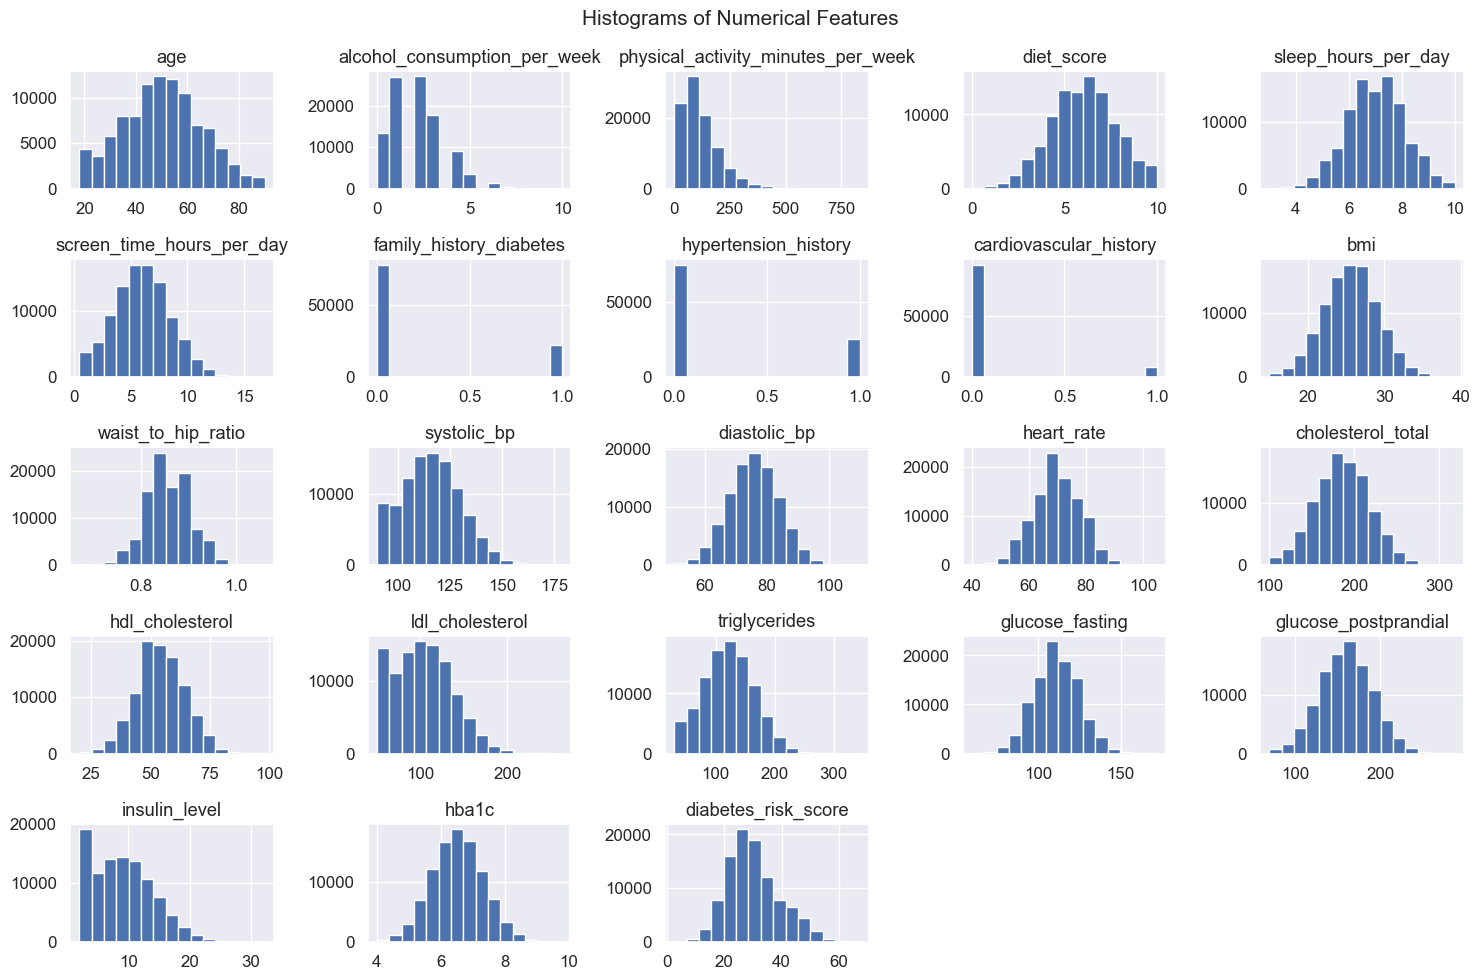

In [12]:
df[numerical_cols].hist(bins=15, figsize=(15,10))
plt.suptitle("Histograms of Numerical Features", fontsize = 15)
plt.tight_layout()
plt.show()

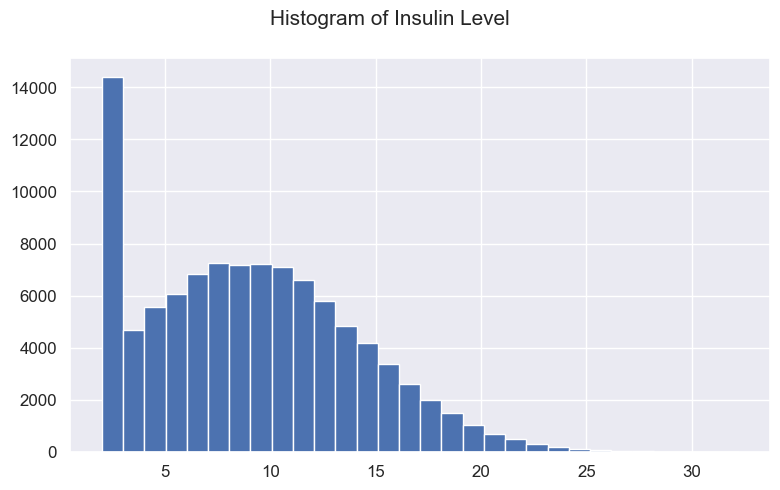

In [13]:
df['insulin_level'].hist(bins=30, figsize=(8,5))
plt.suptitle("Histogram of Insulin Level", fontsize = 15)
plt.tight_layout()
plt.show()

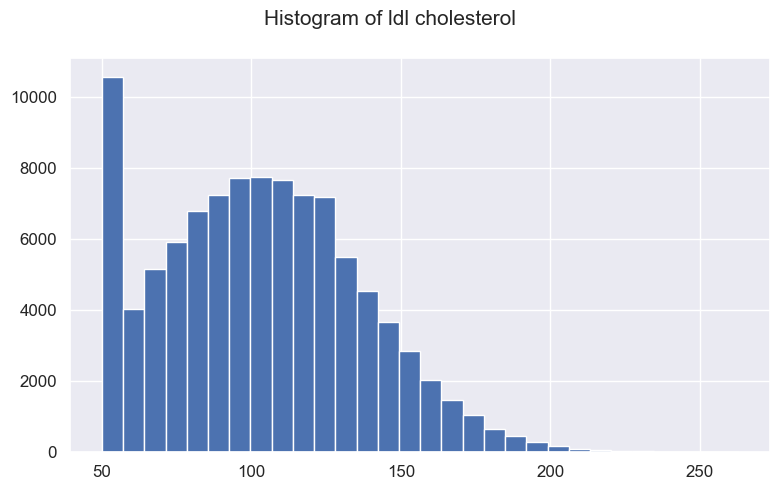

In [14]:
df['ldl_cholesterol'].hist(bins=30, figsize=(8,5))
plt.suptitle("Histogram of ldl cholesterol", fontsize = 15)
plt.tight_layout()
plt.show()

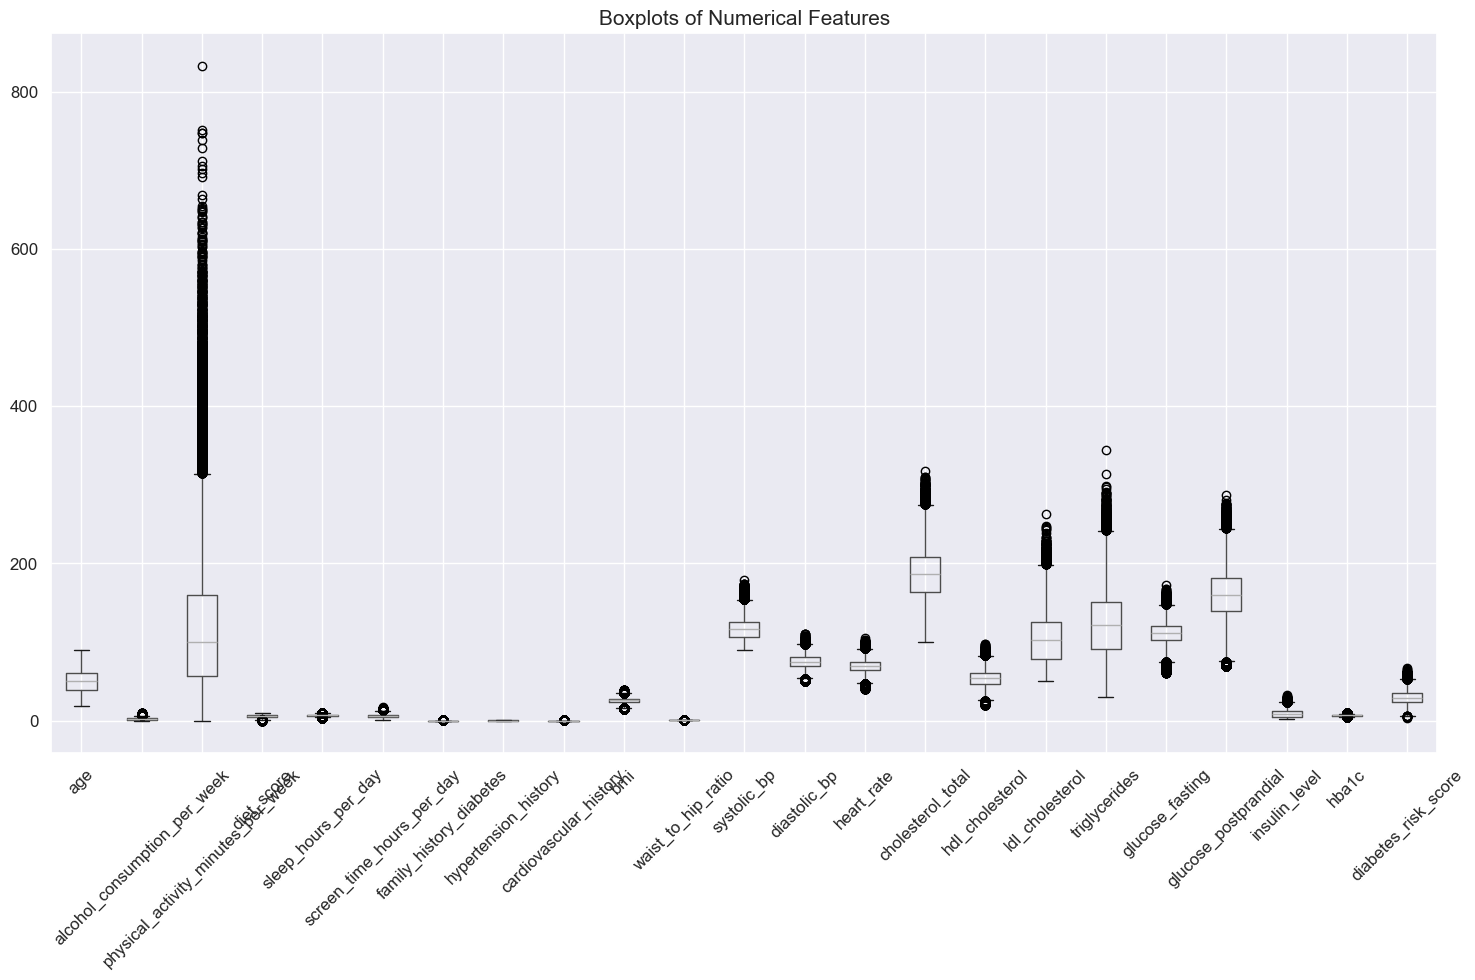

In [15]:
plt.figure(figsize=(15,10))
df[numerical_cols].boxplot()
plt.title("Boxplots of Numerical Features", fontsize=15)
plt.xticks(rotation = 45)
plt.tight_layout()
plt.show()

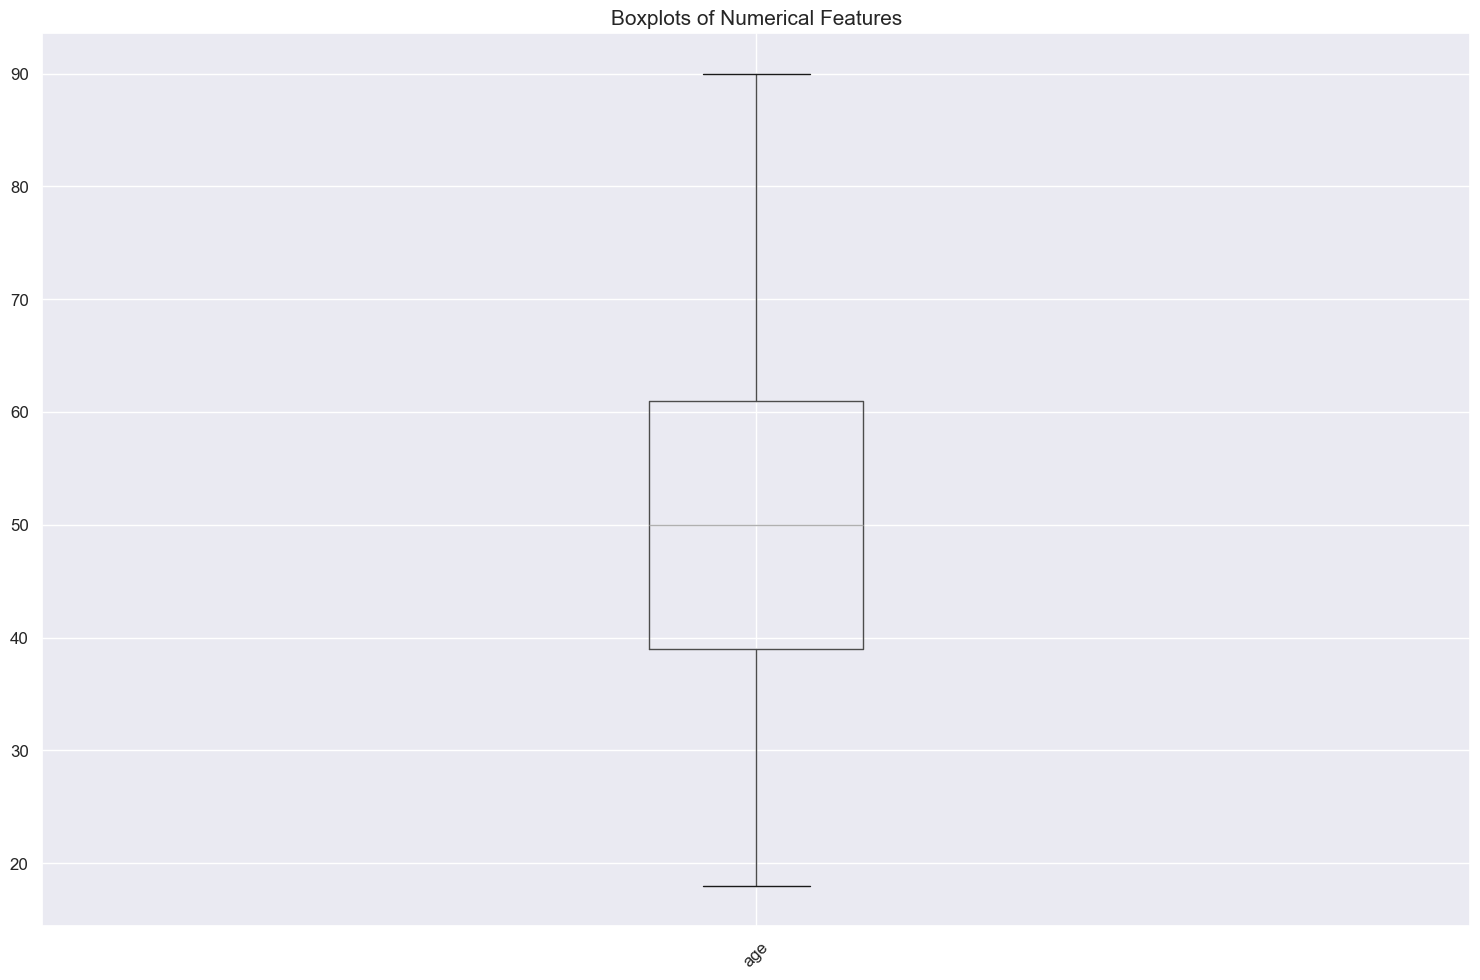

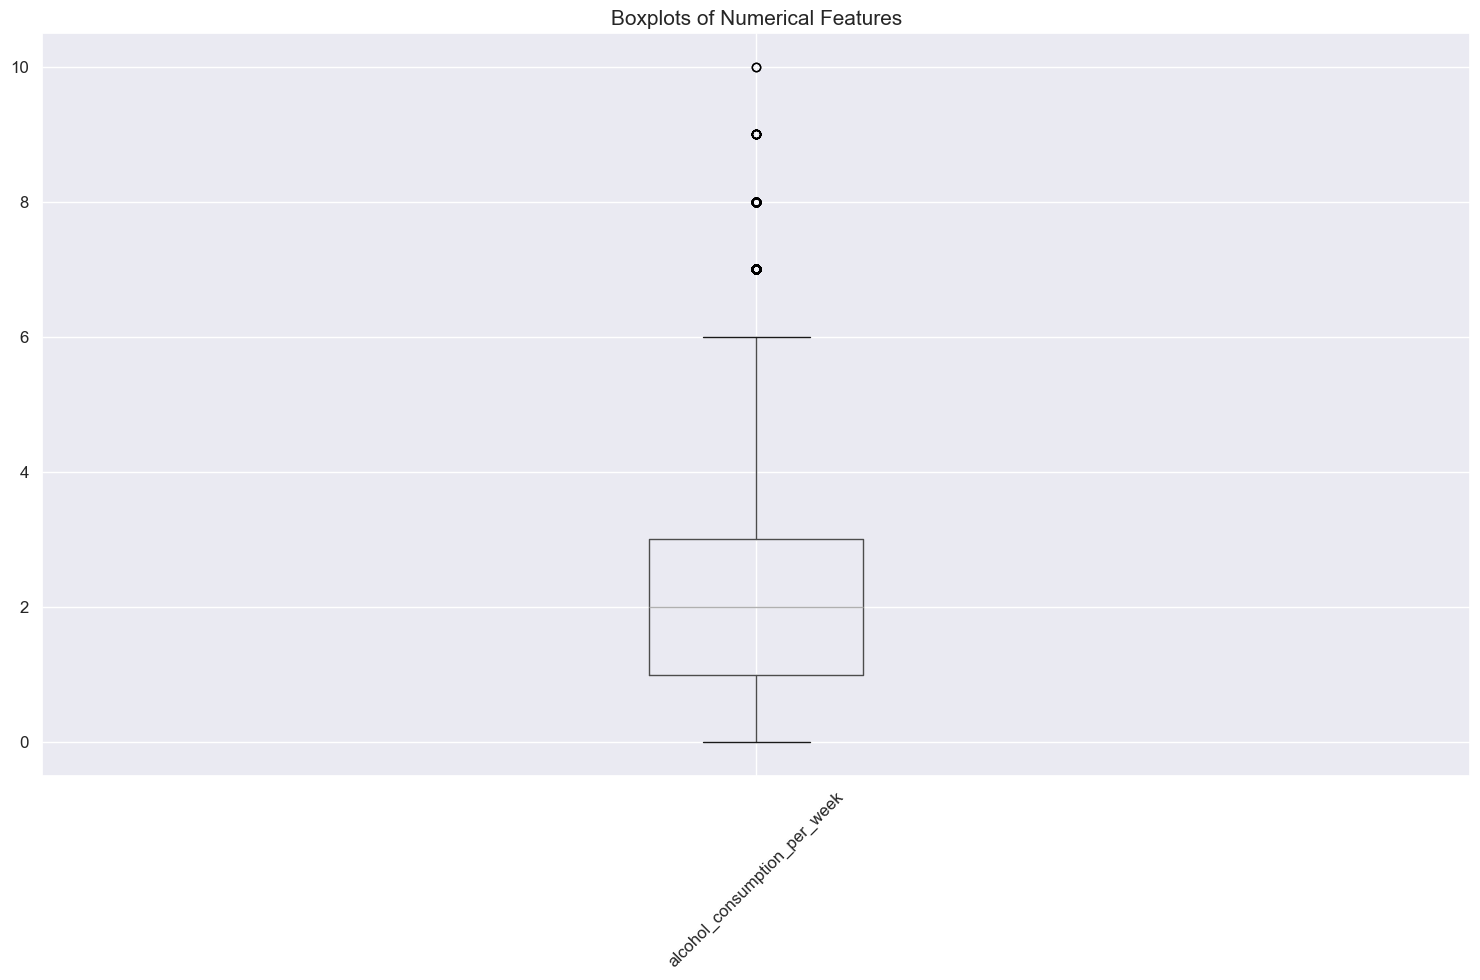

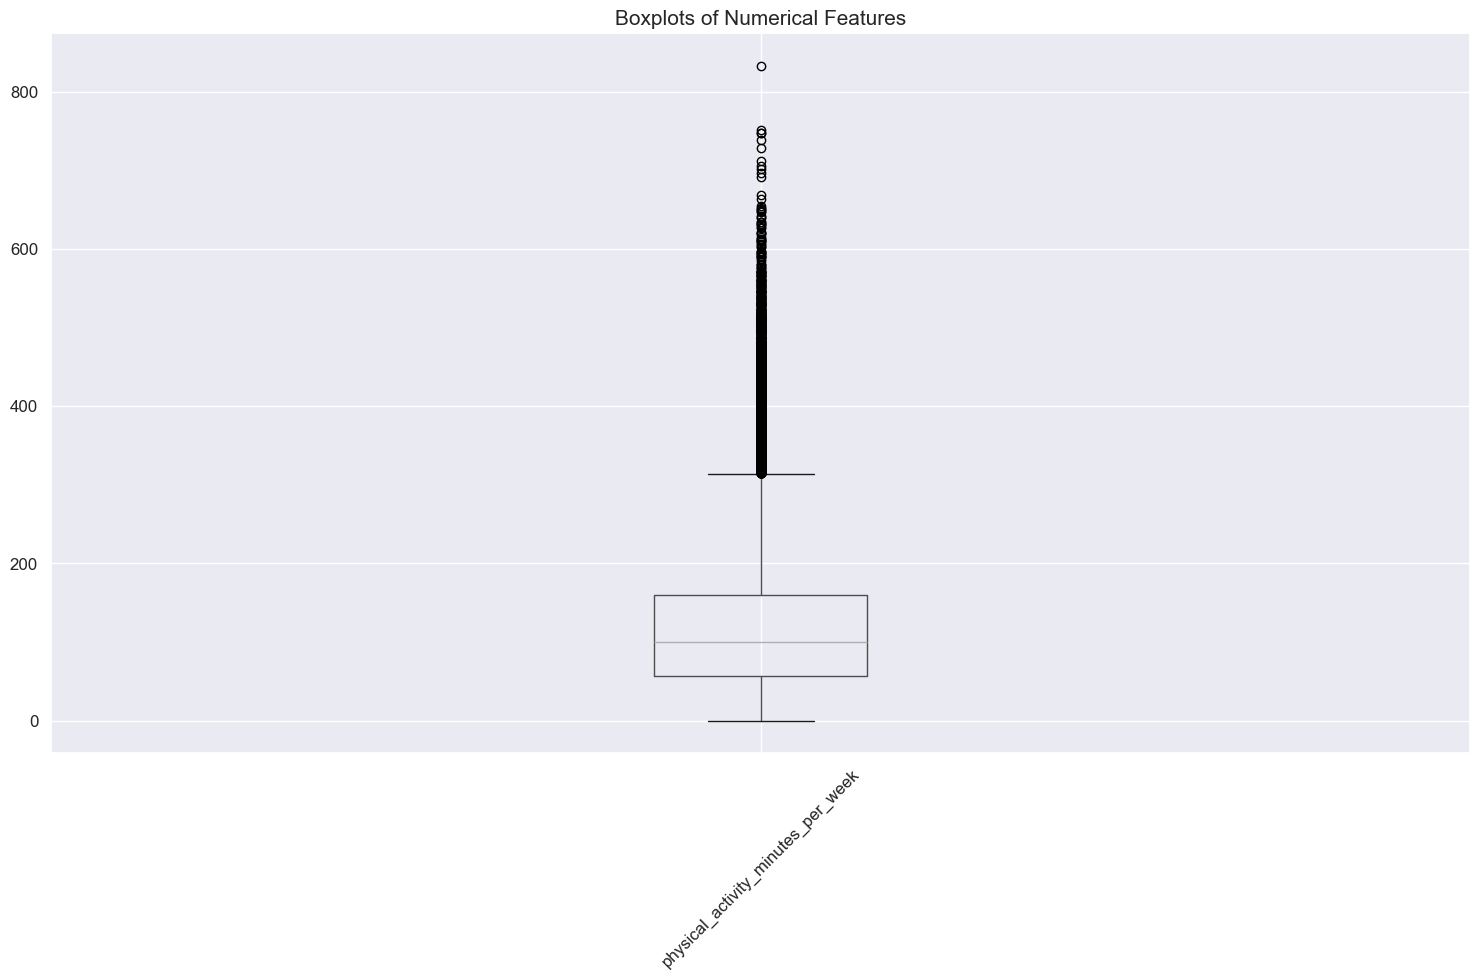

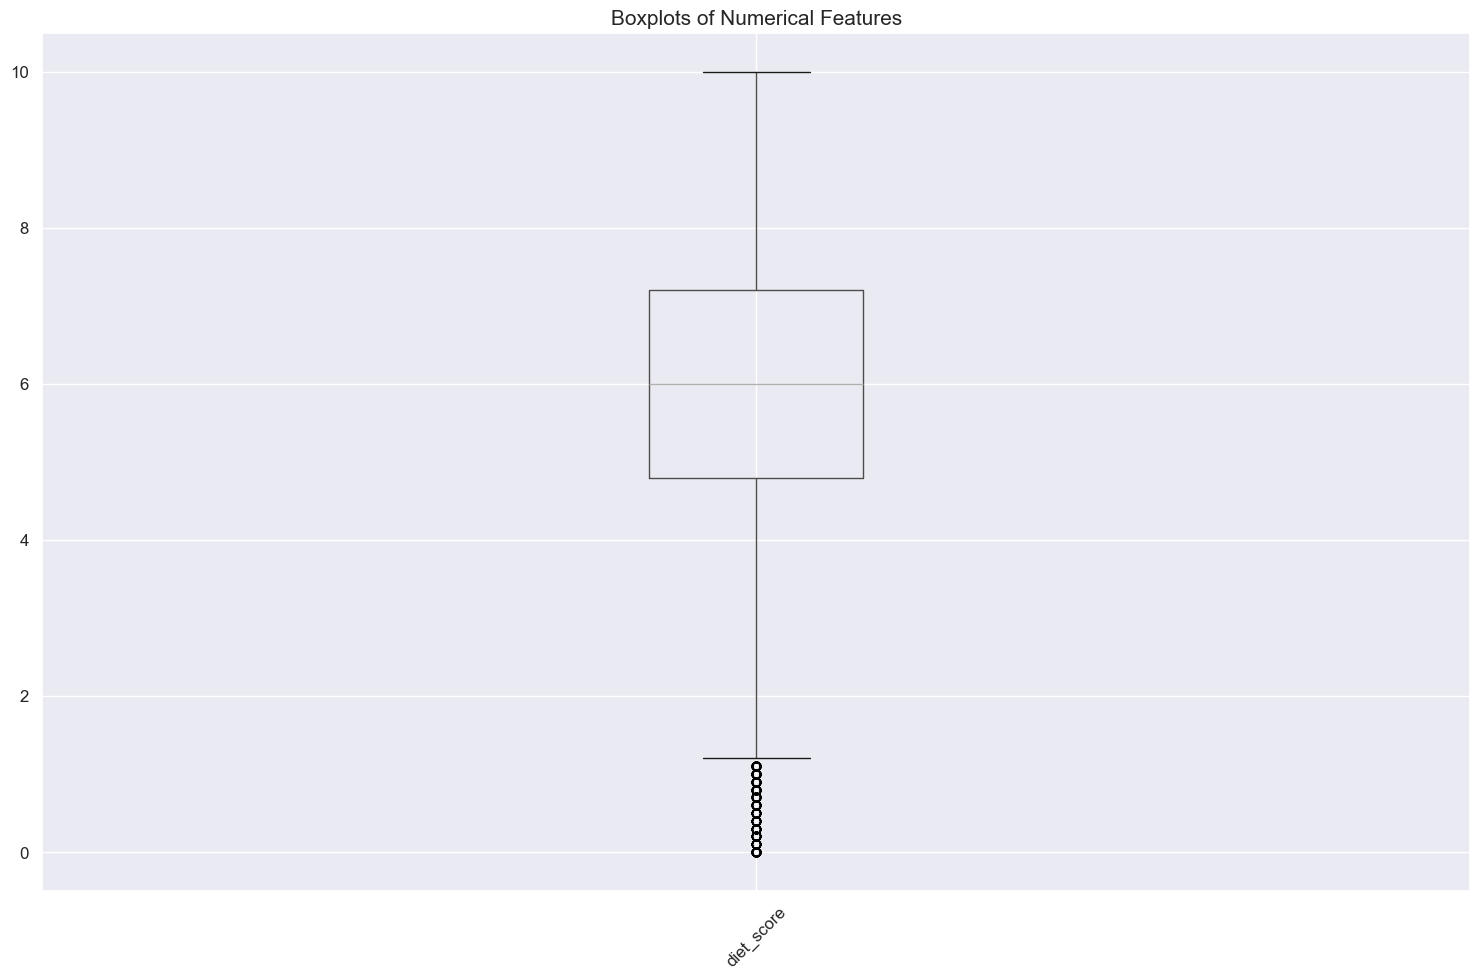

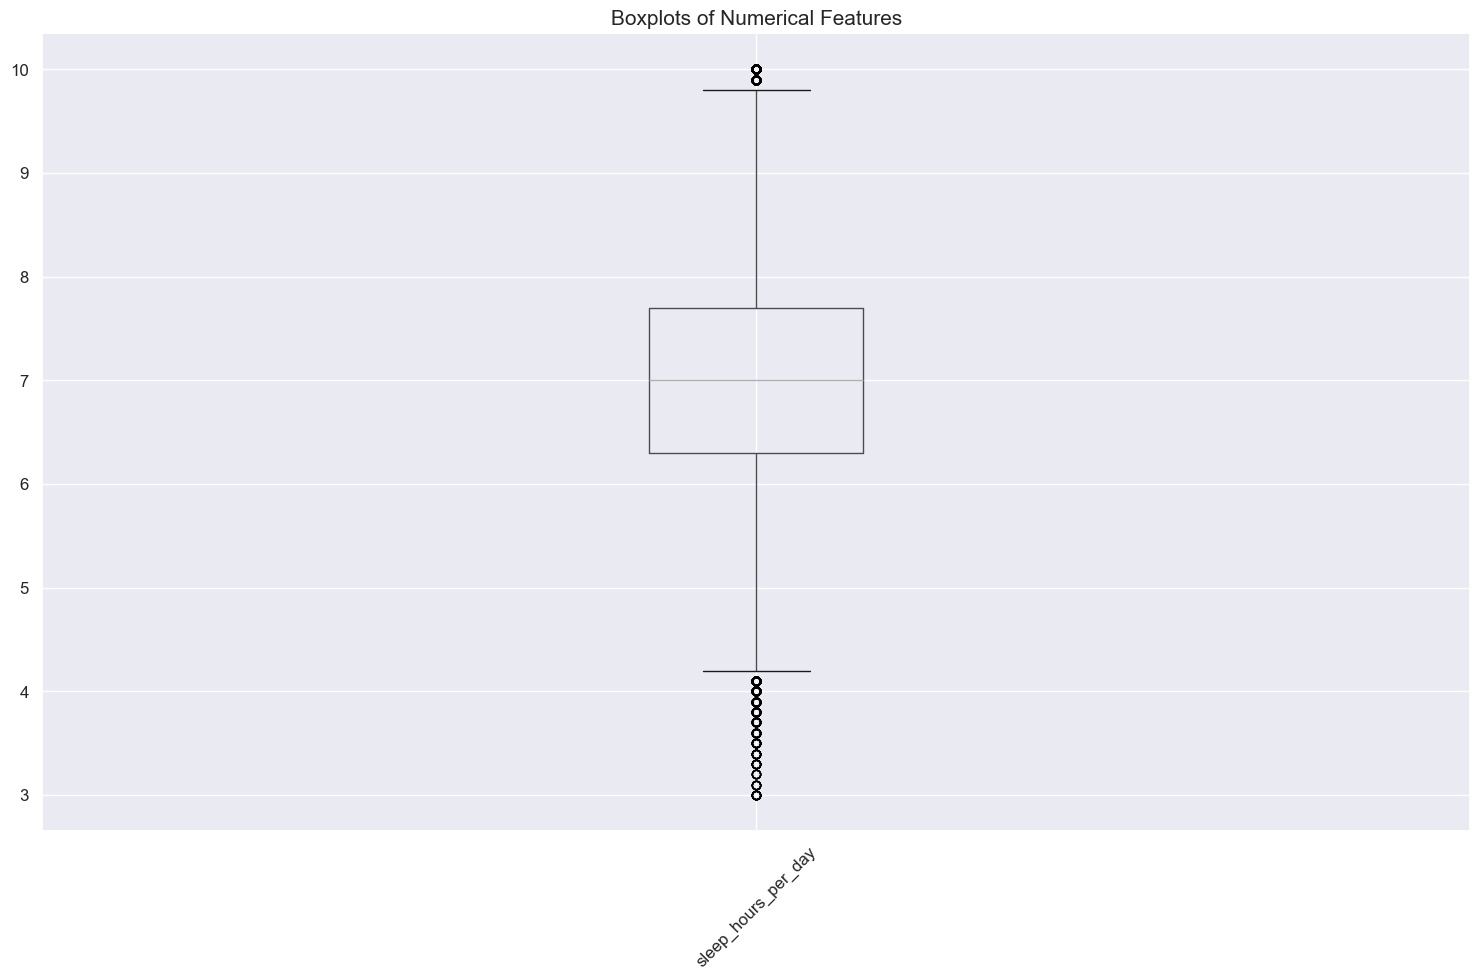

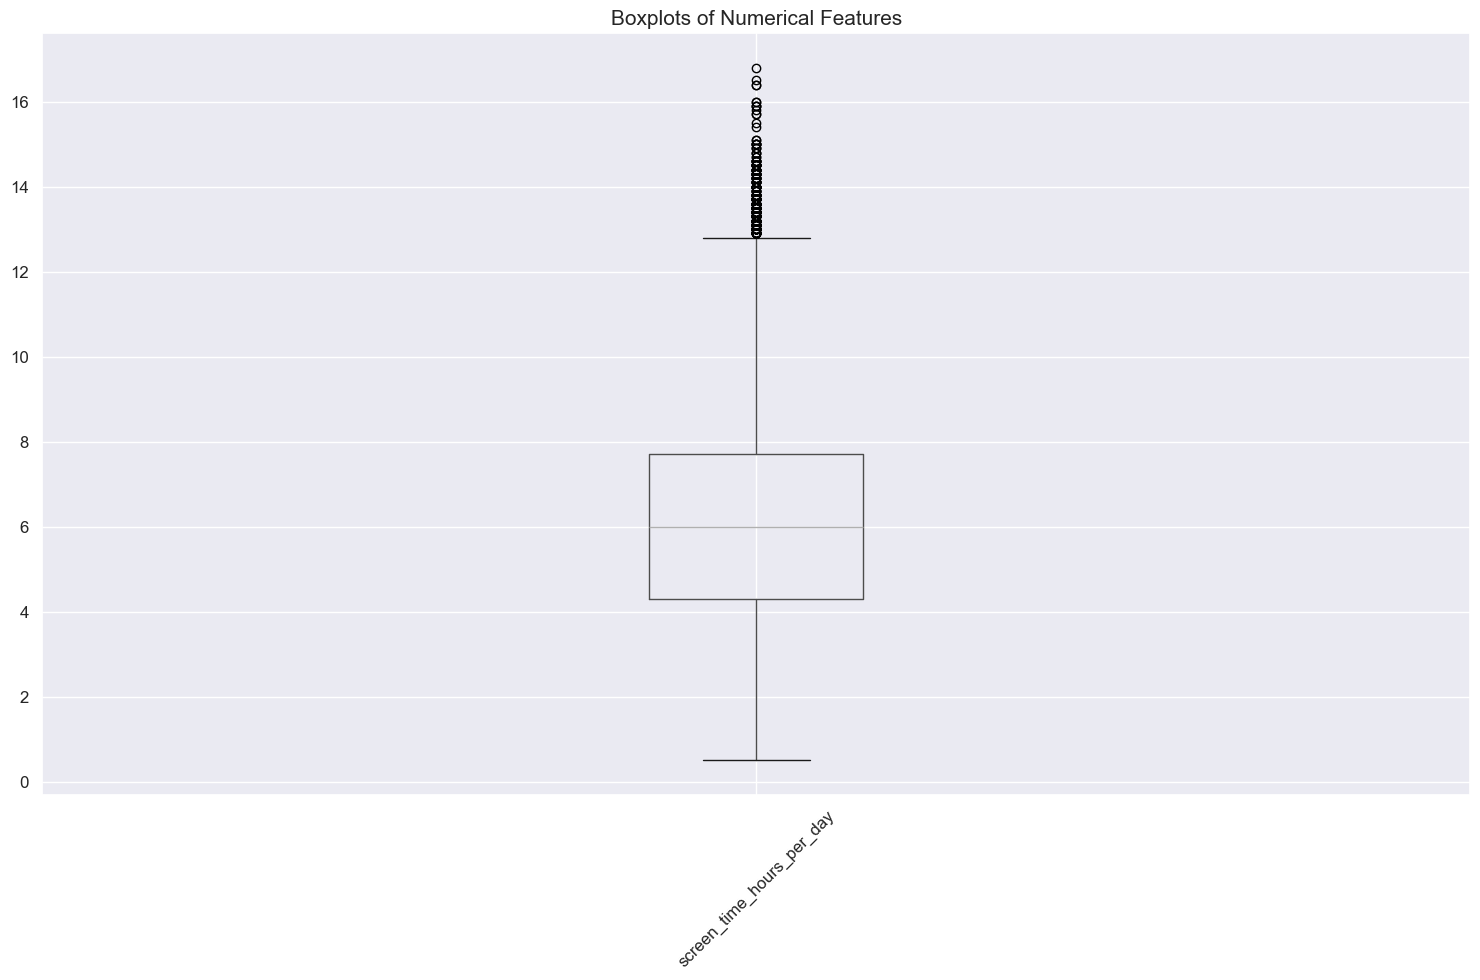

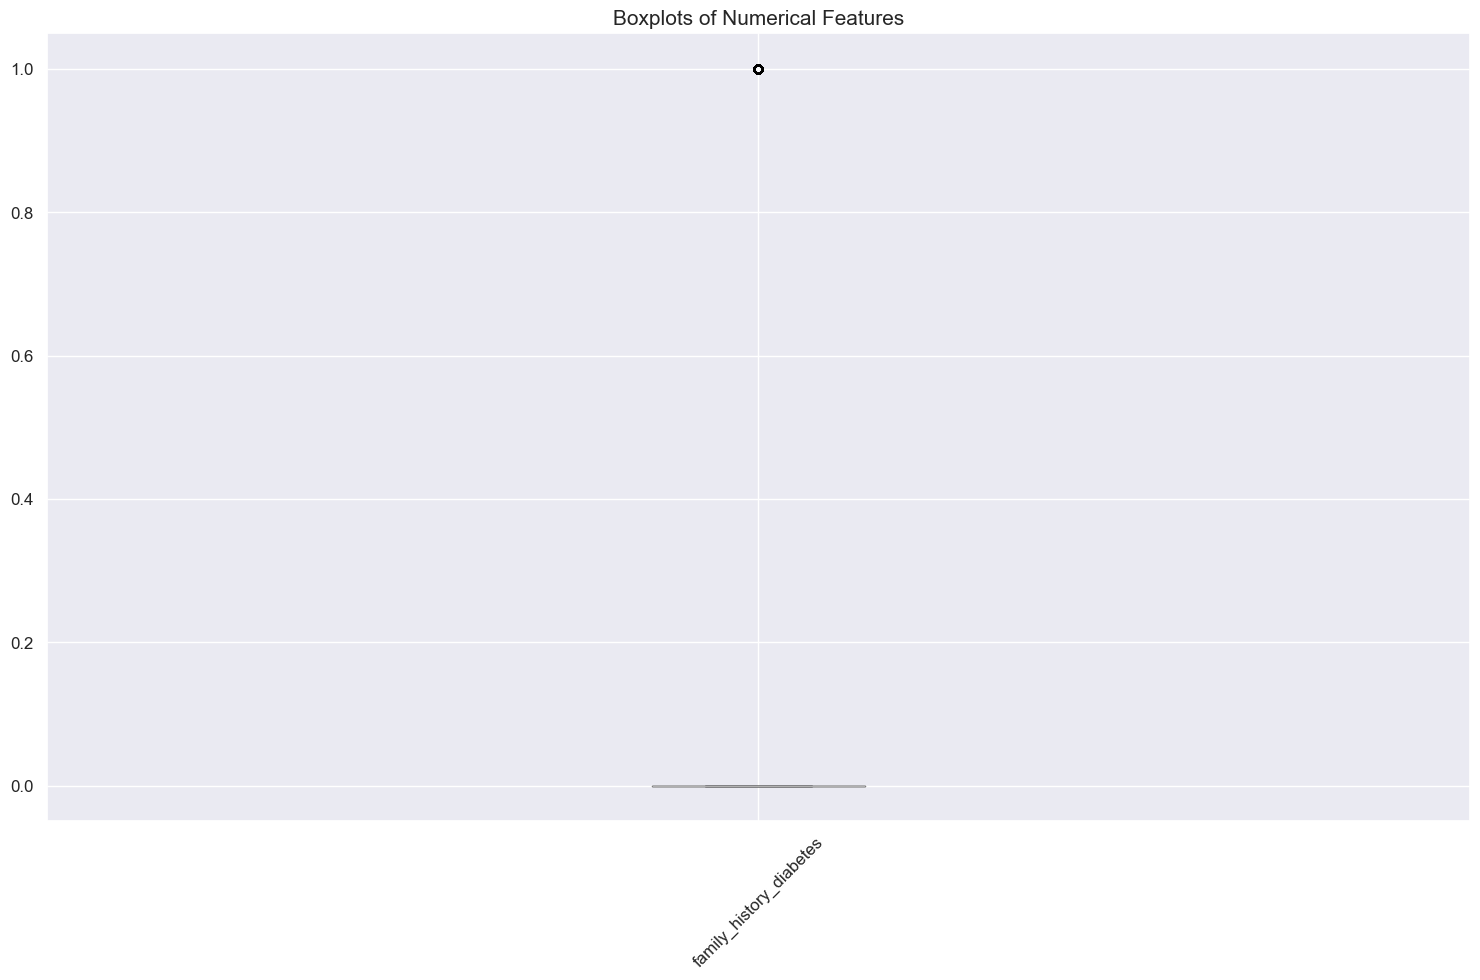

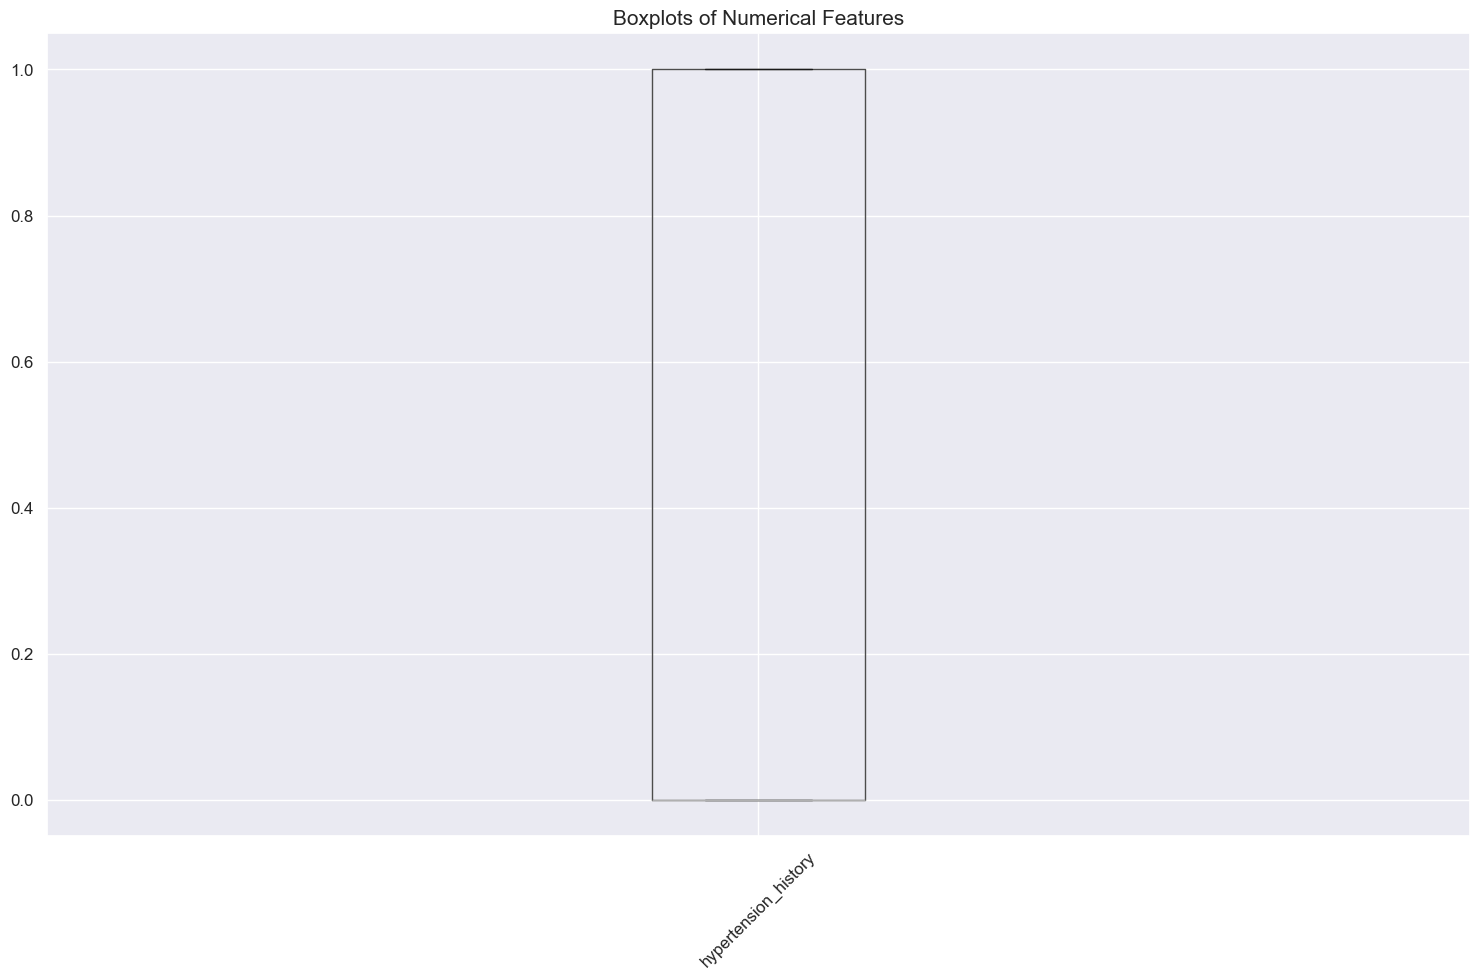

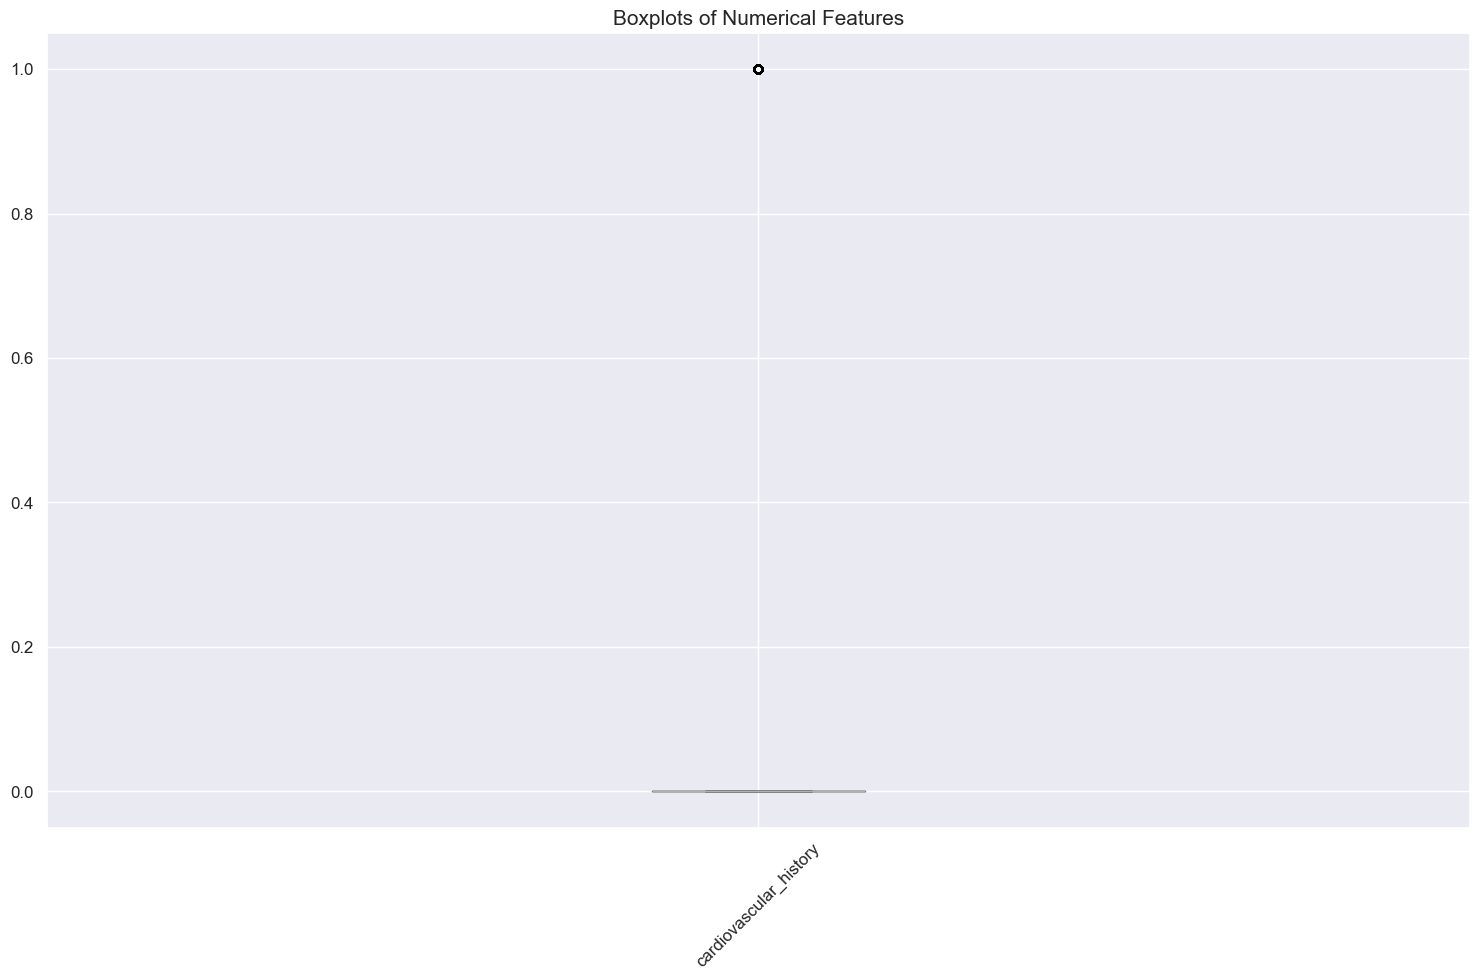

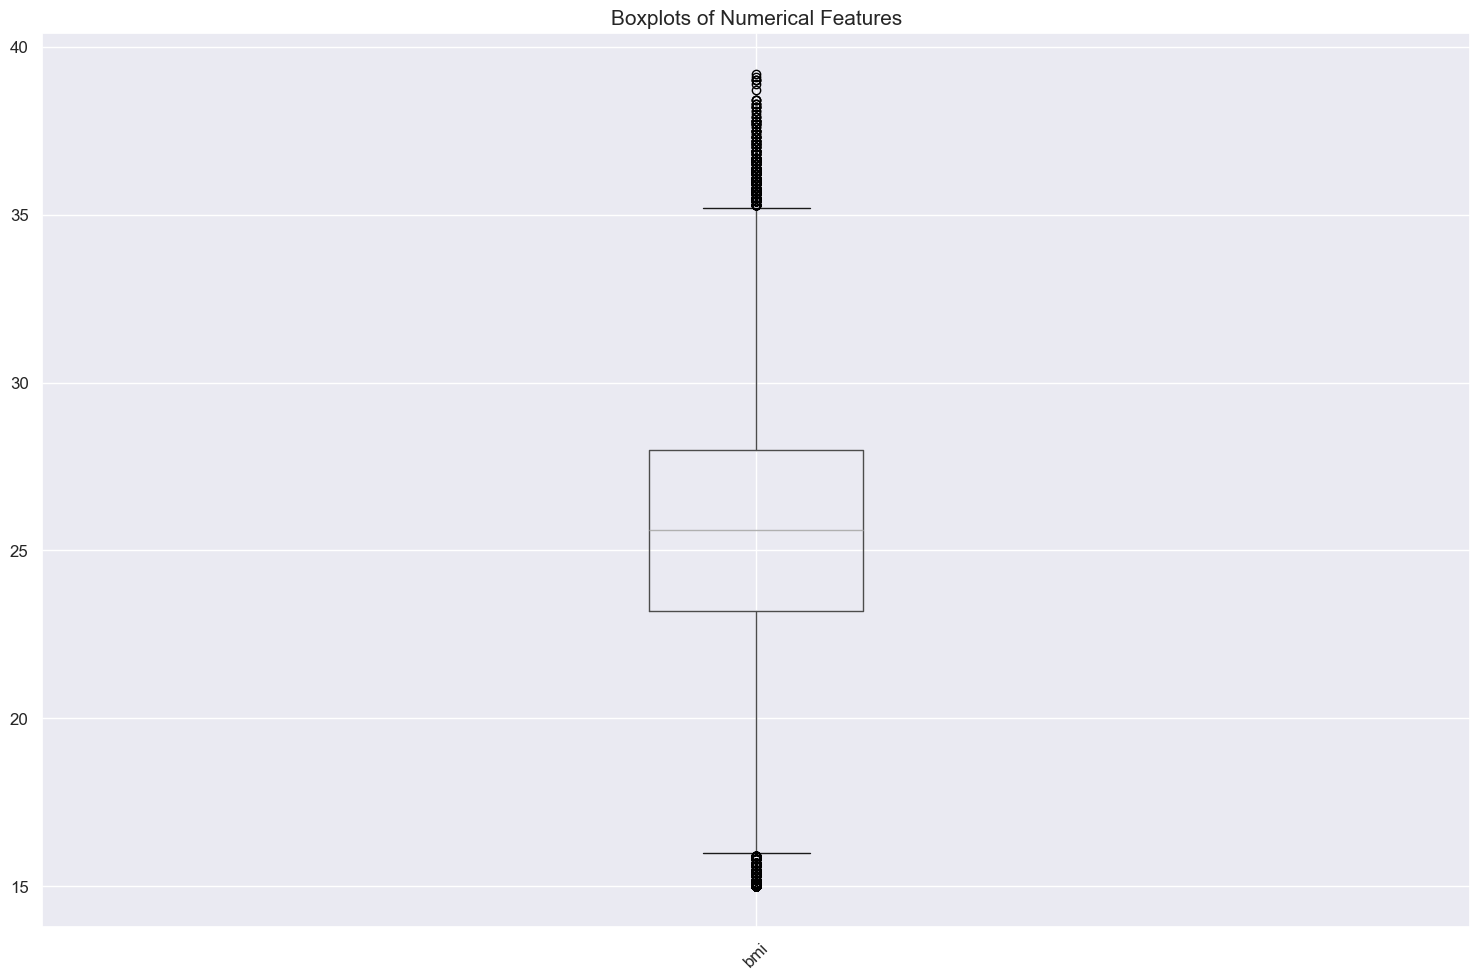

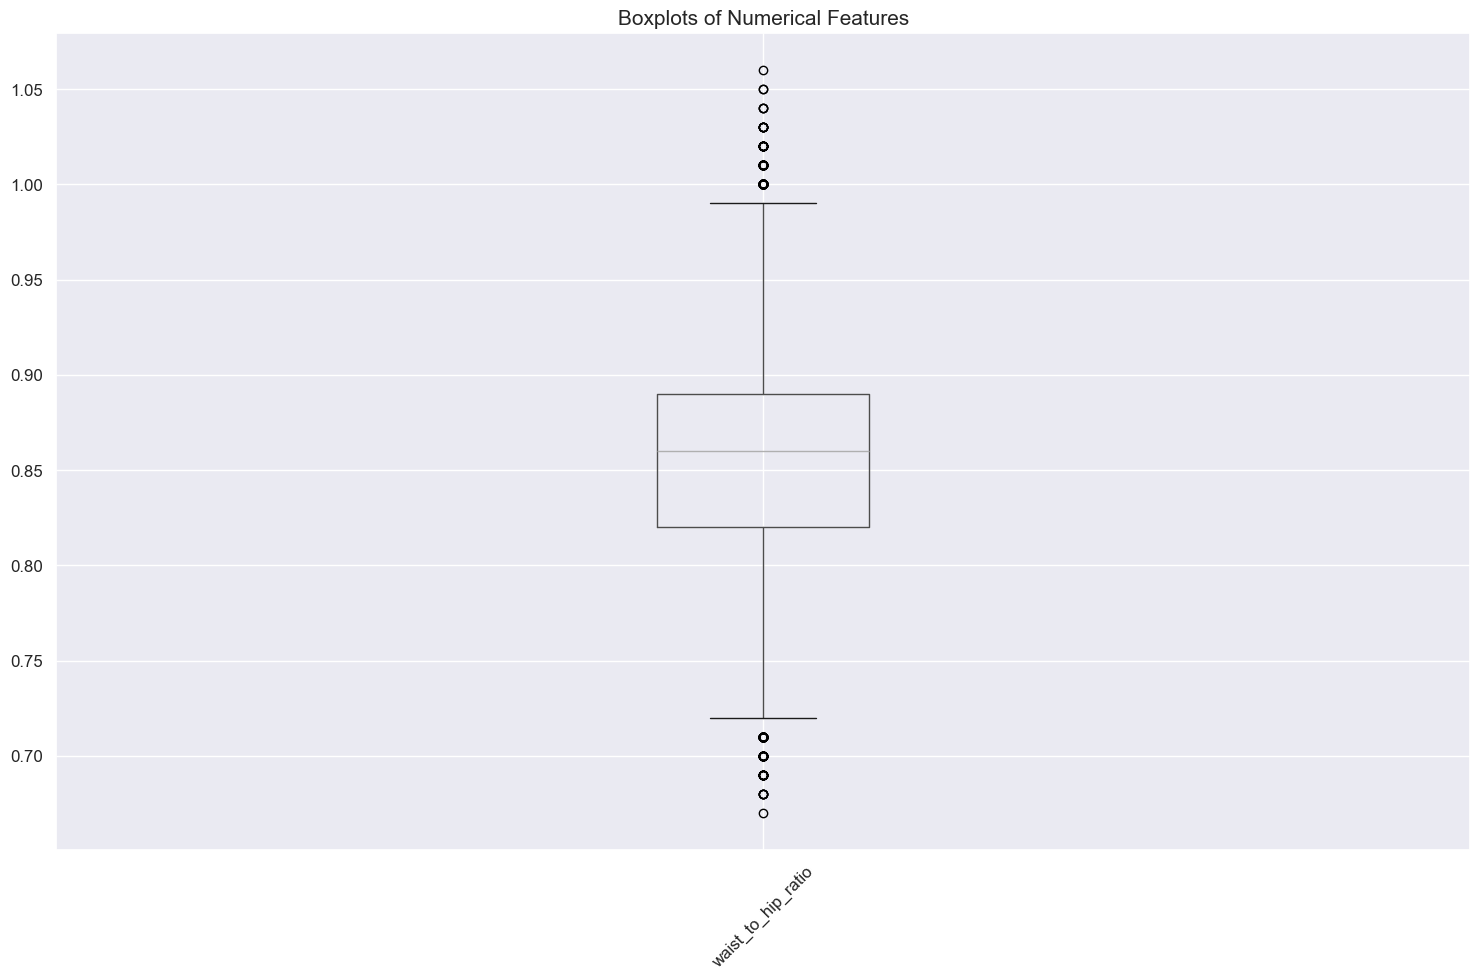

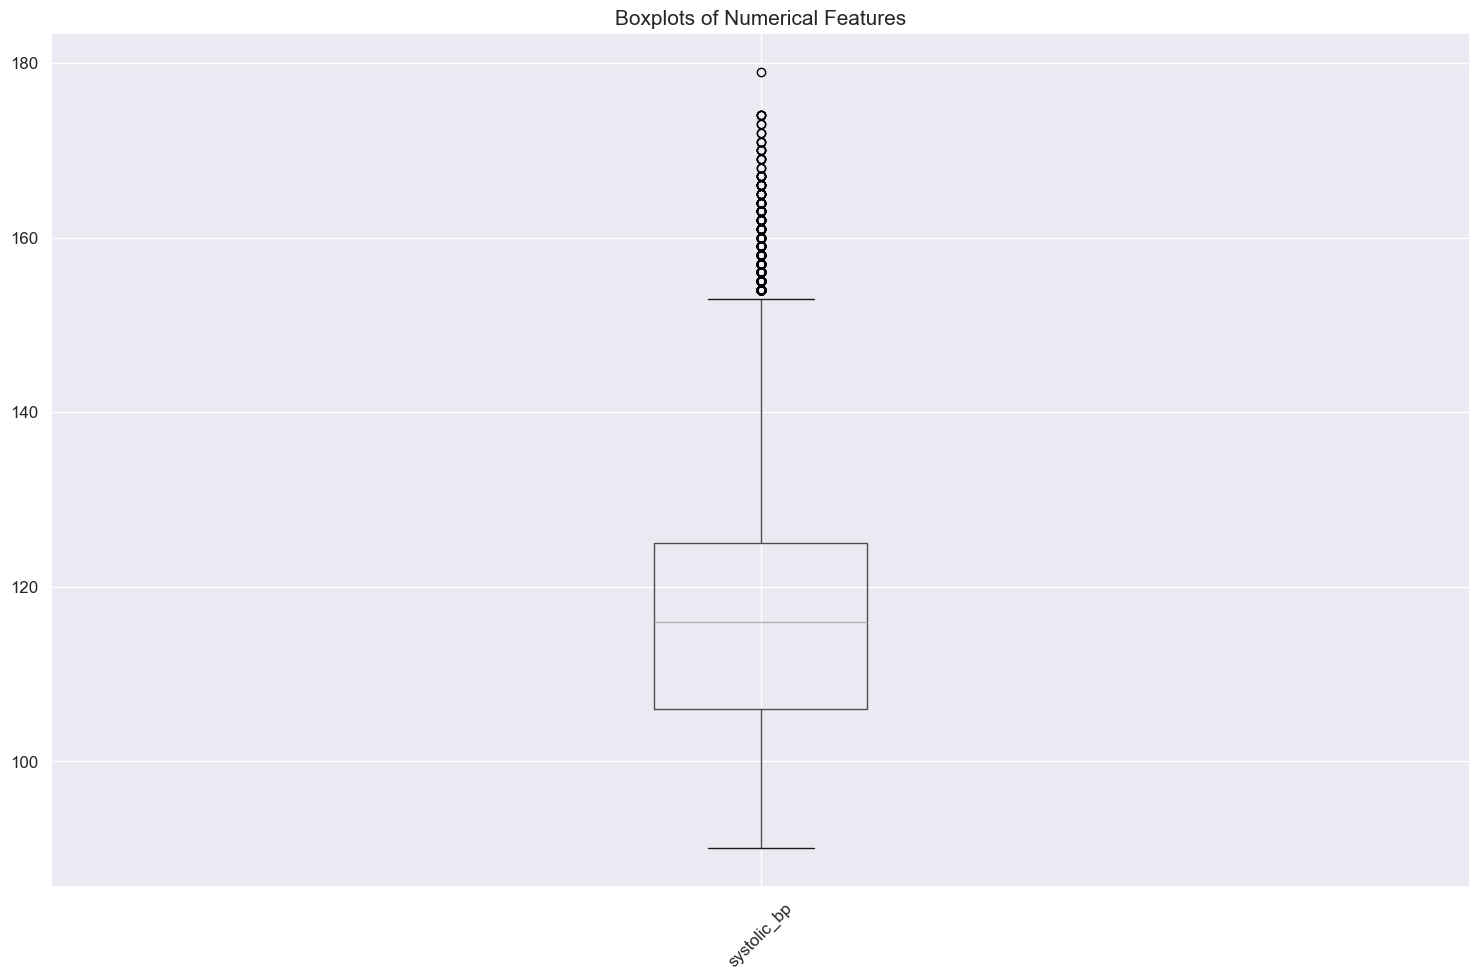

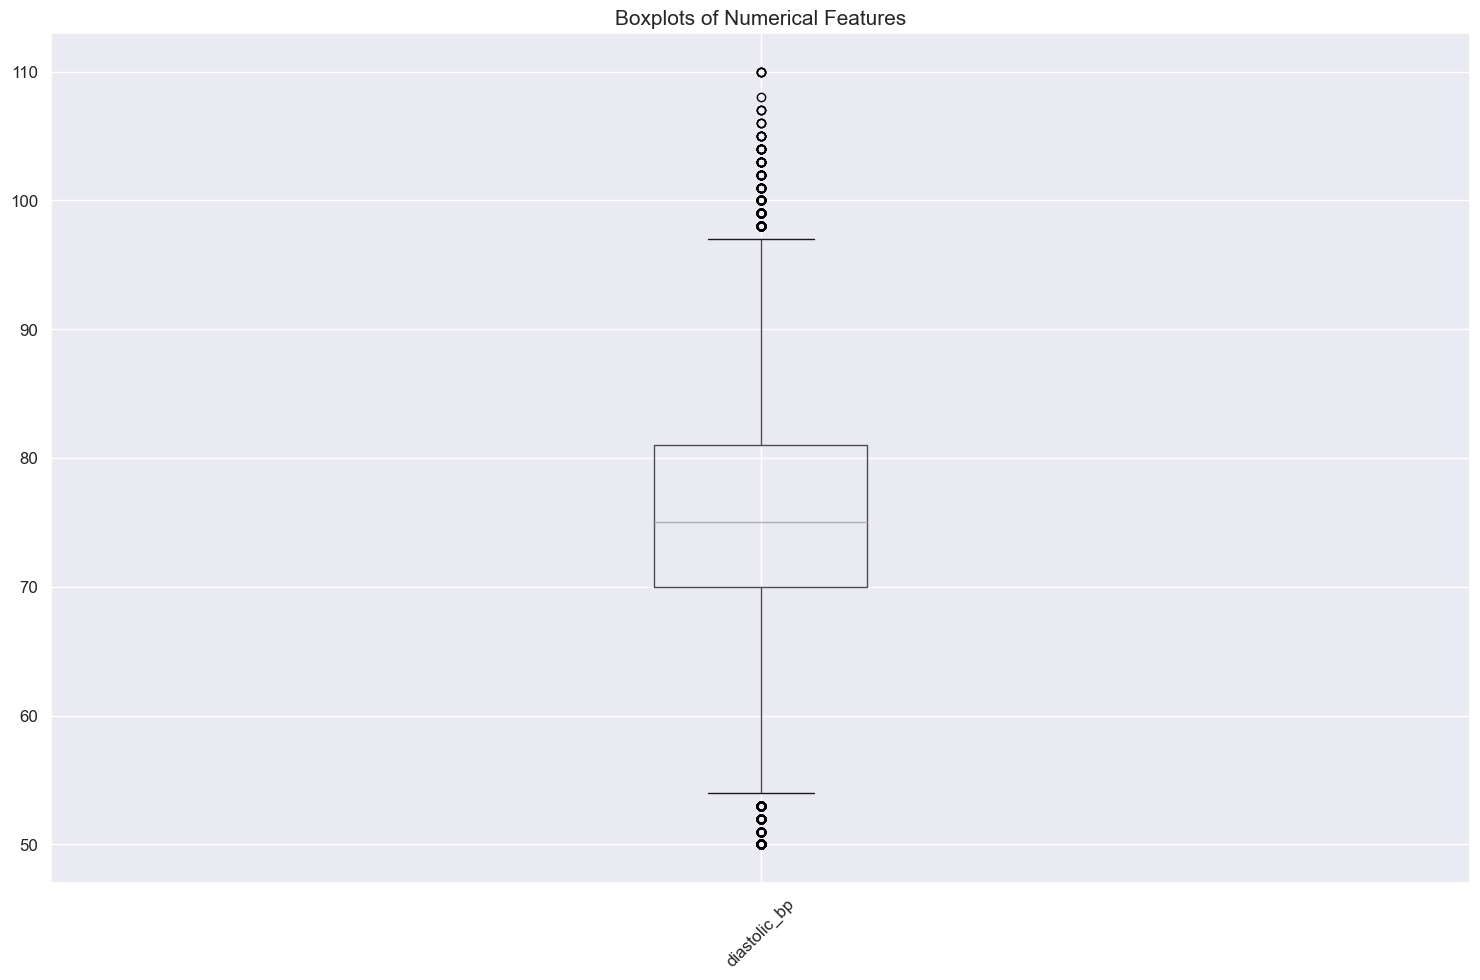

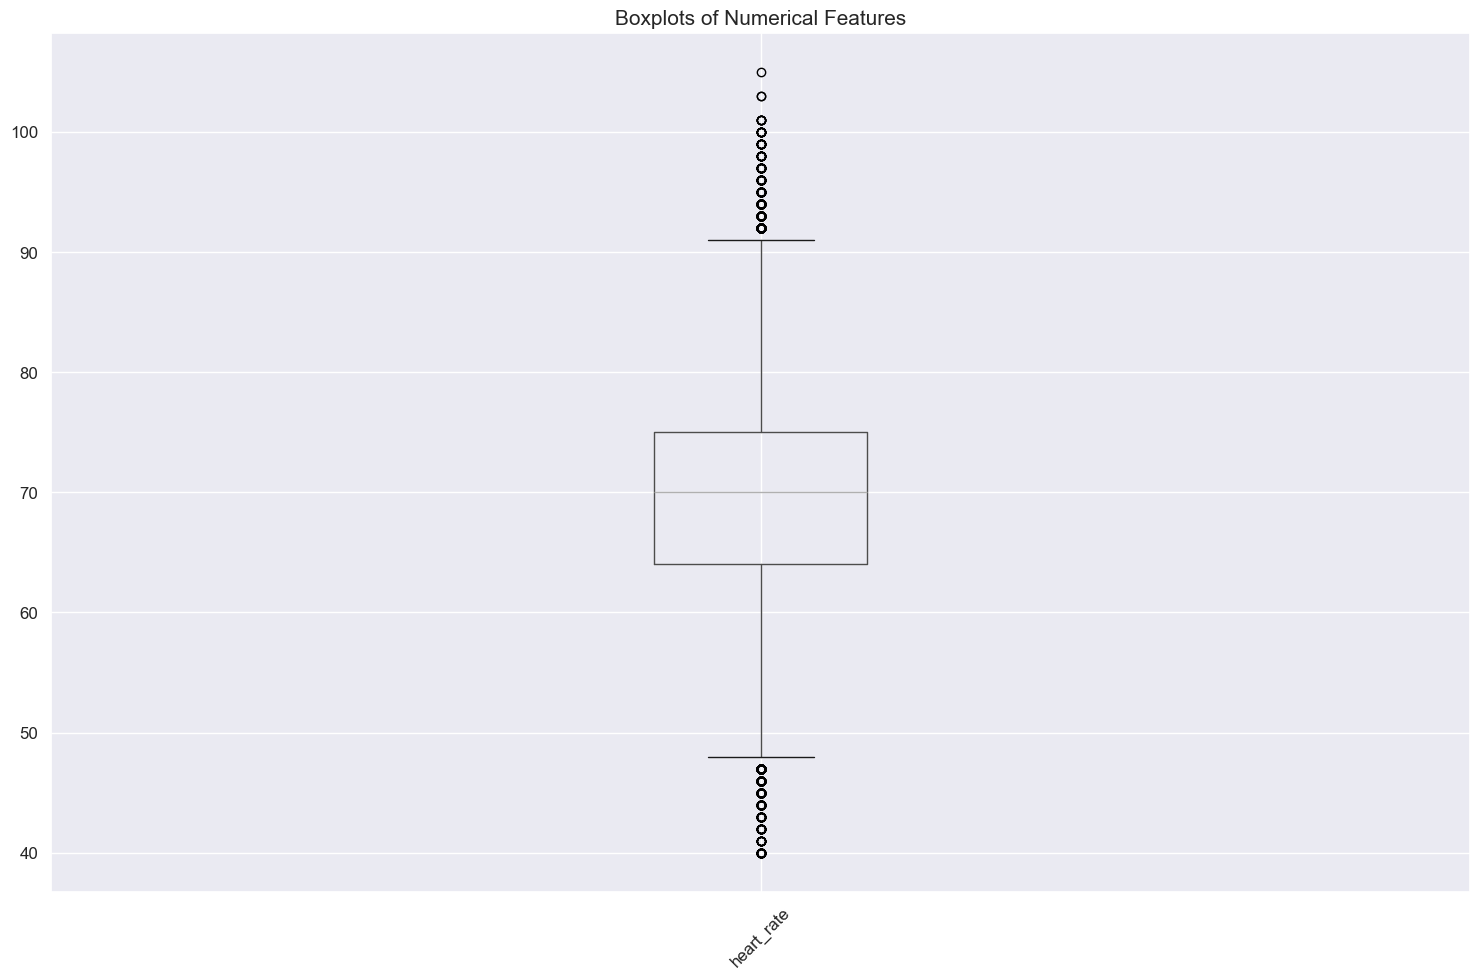

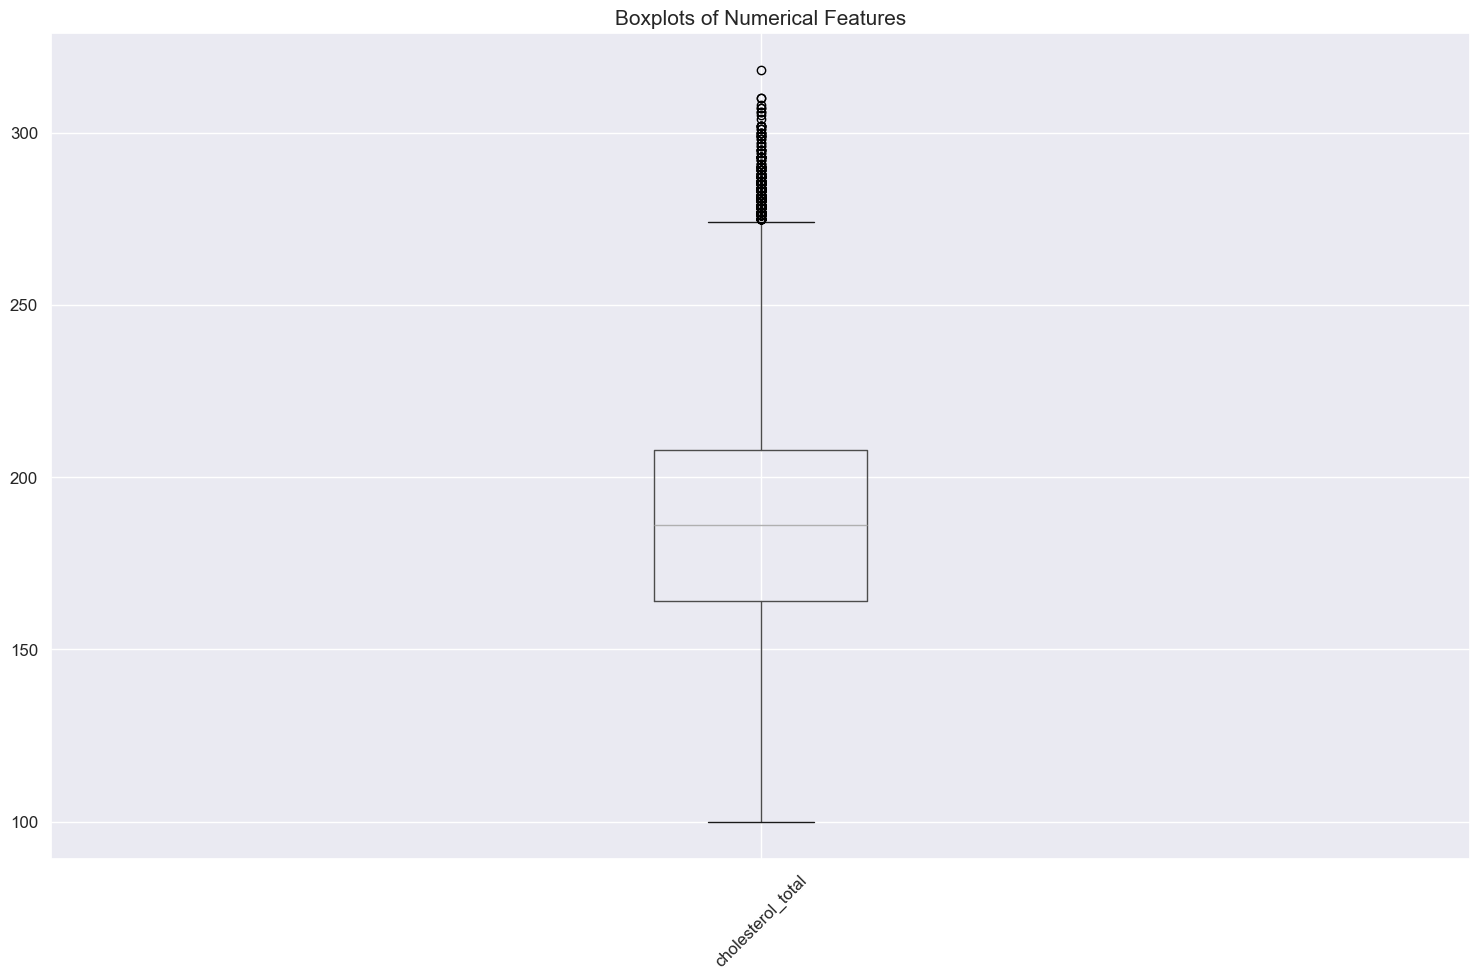

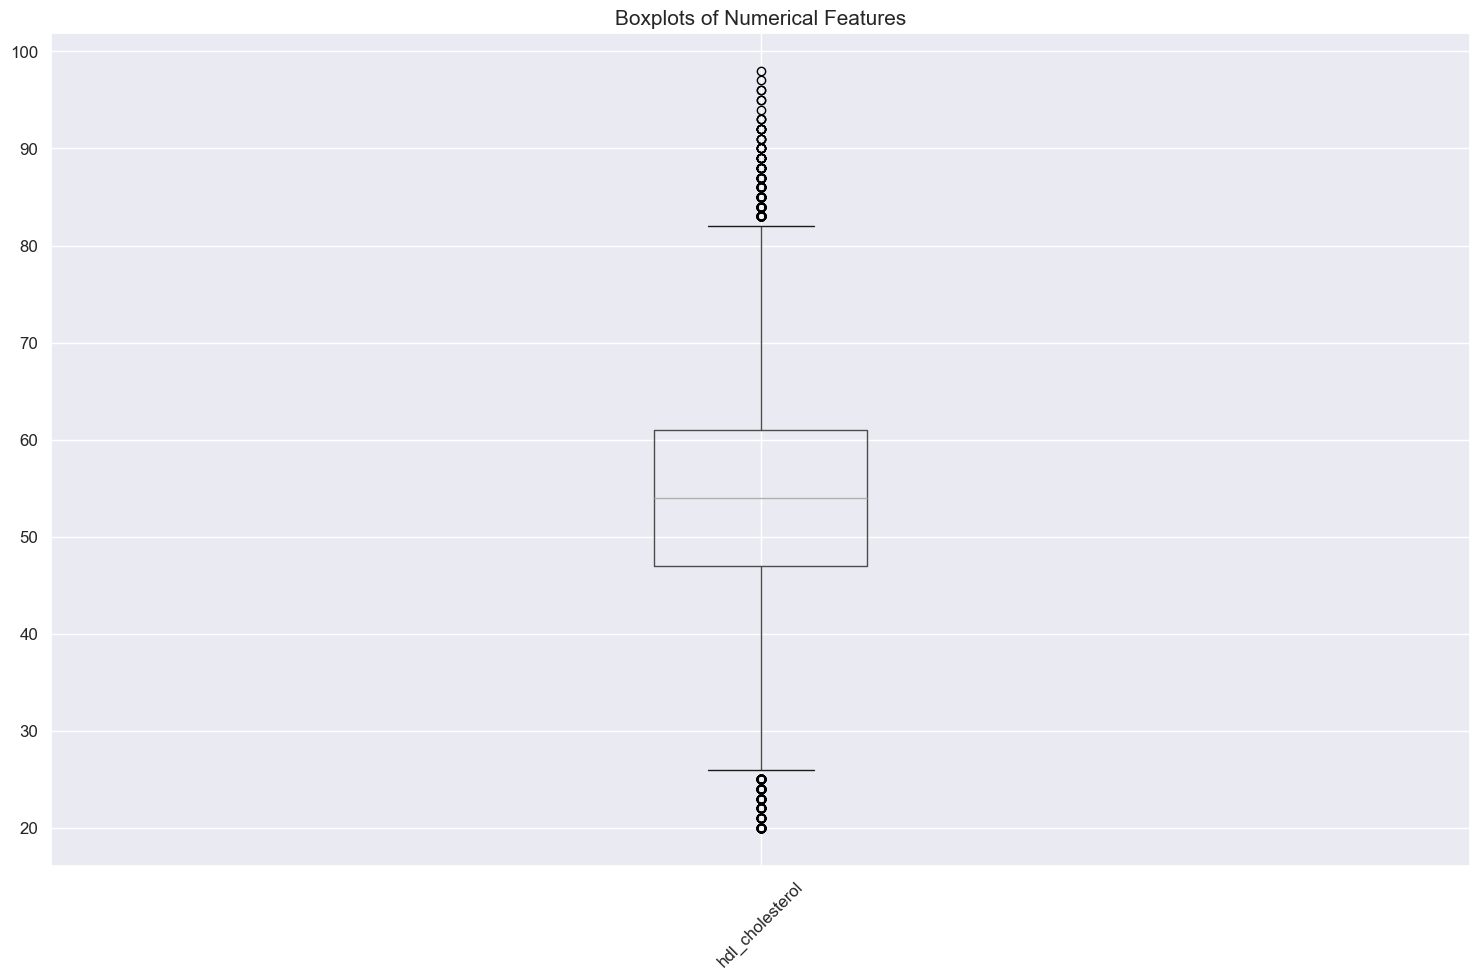

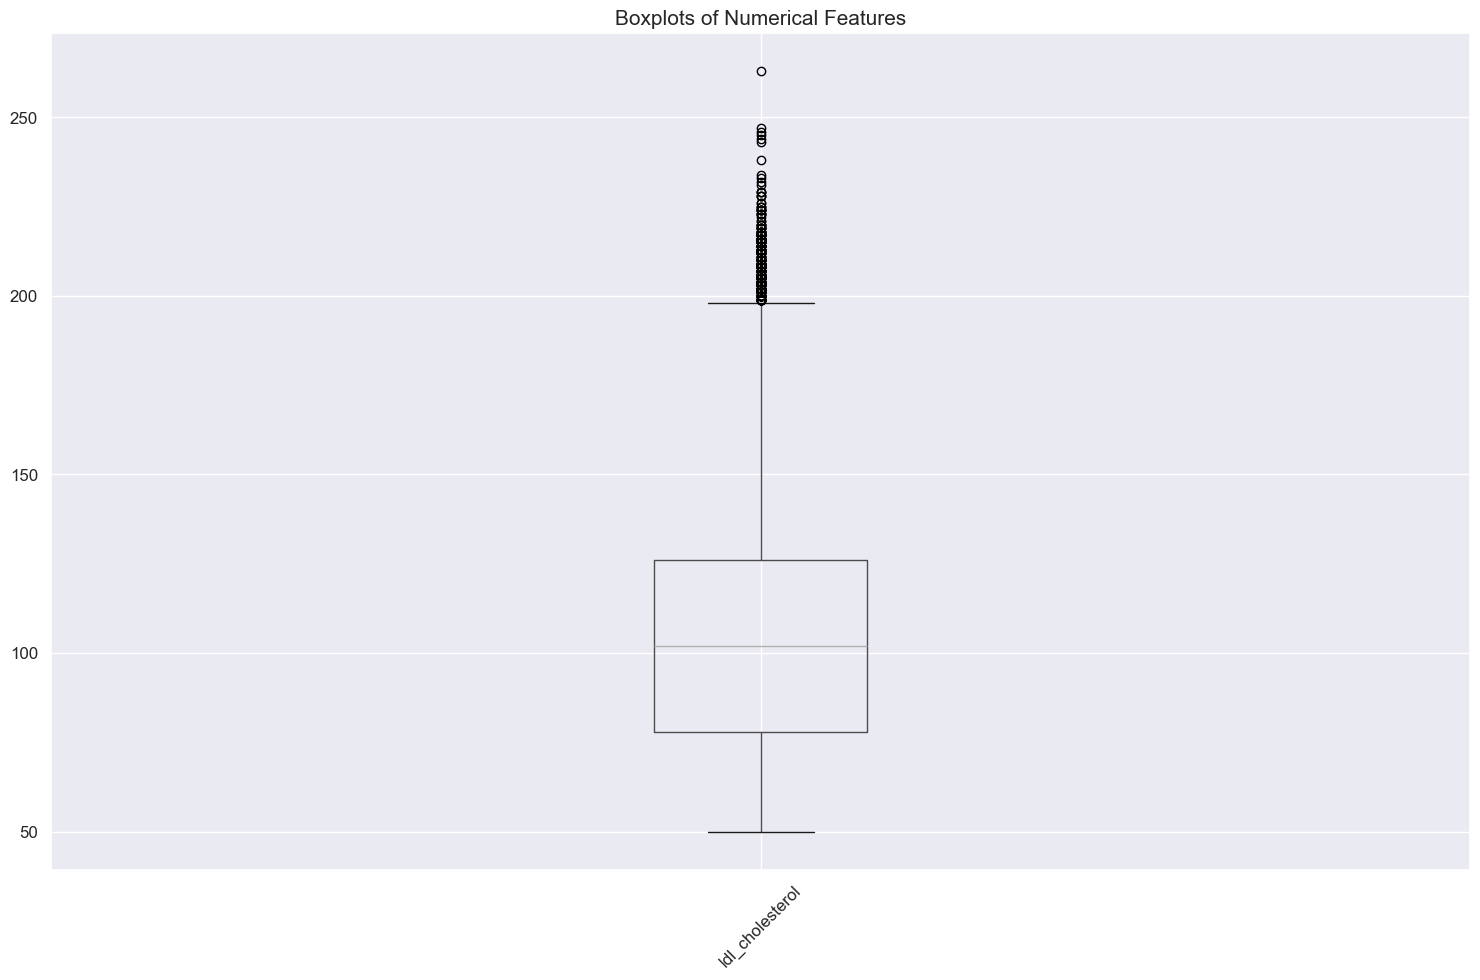

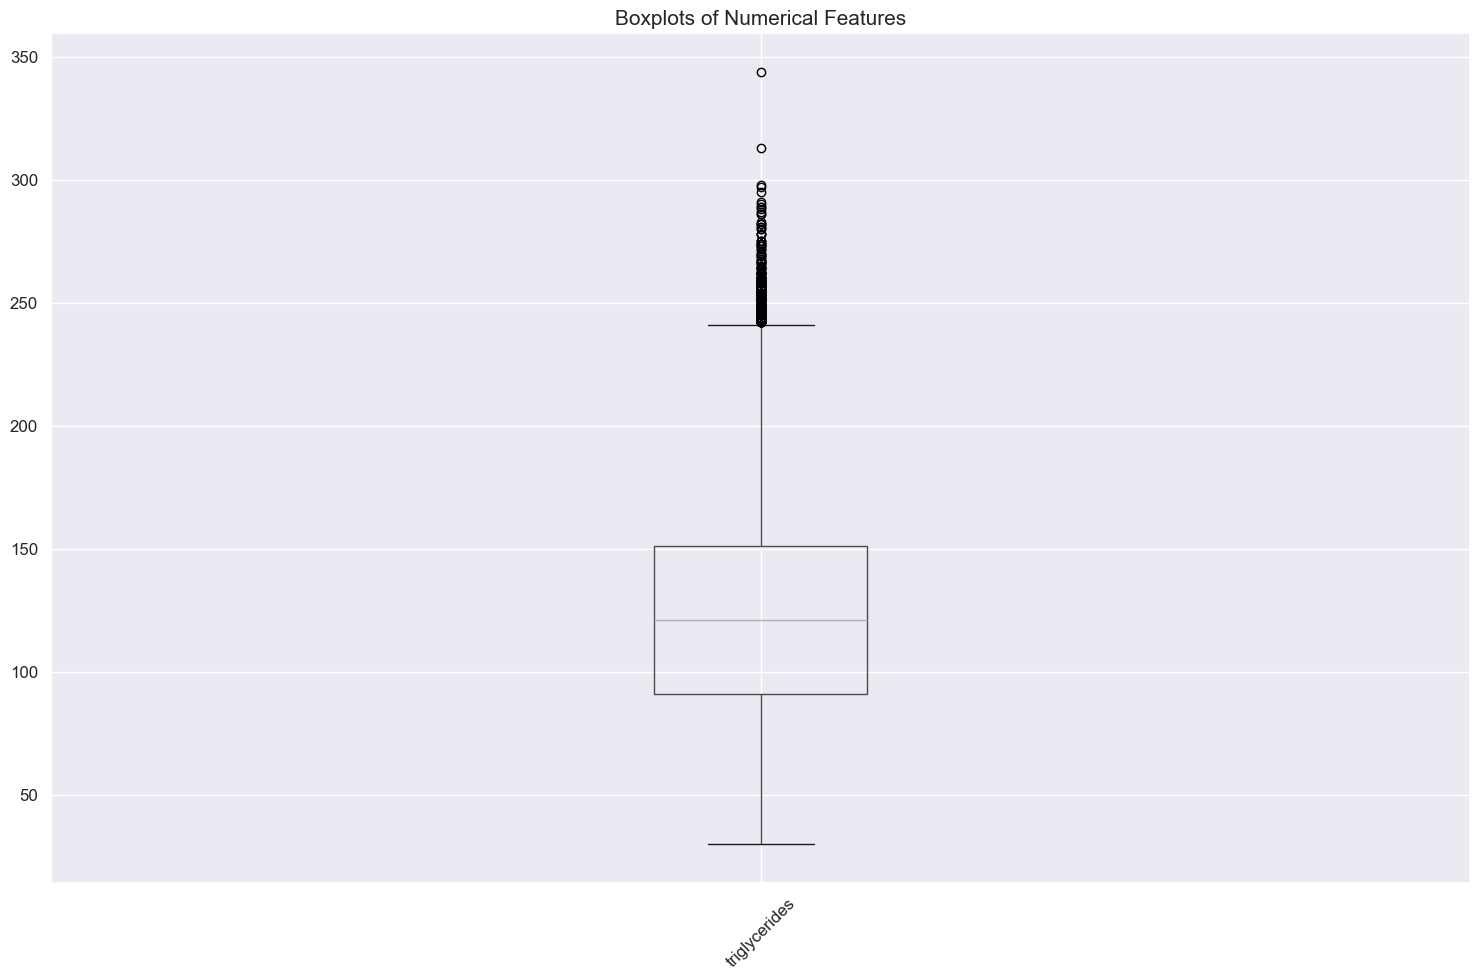

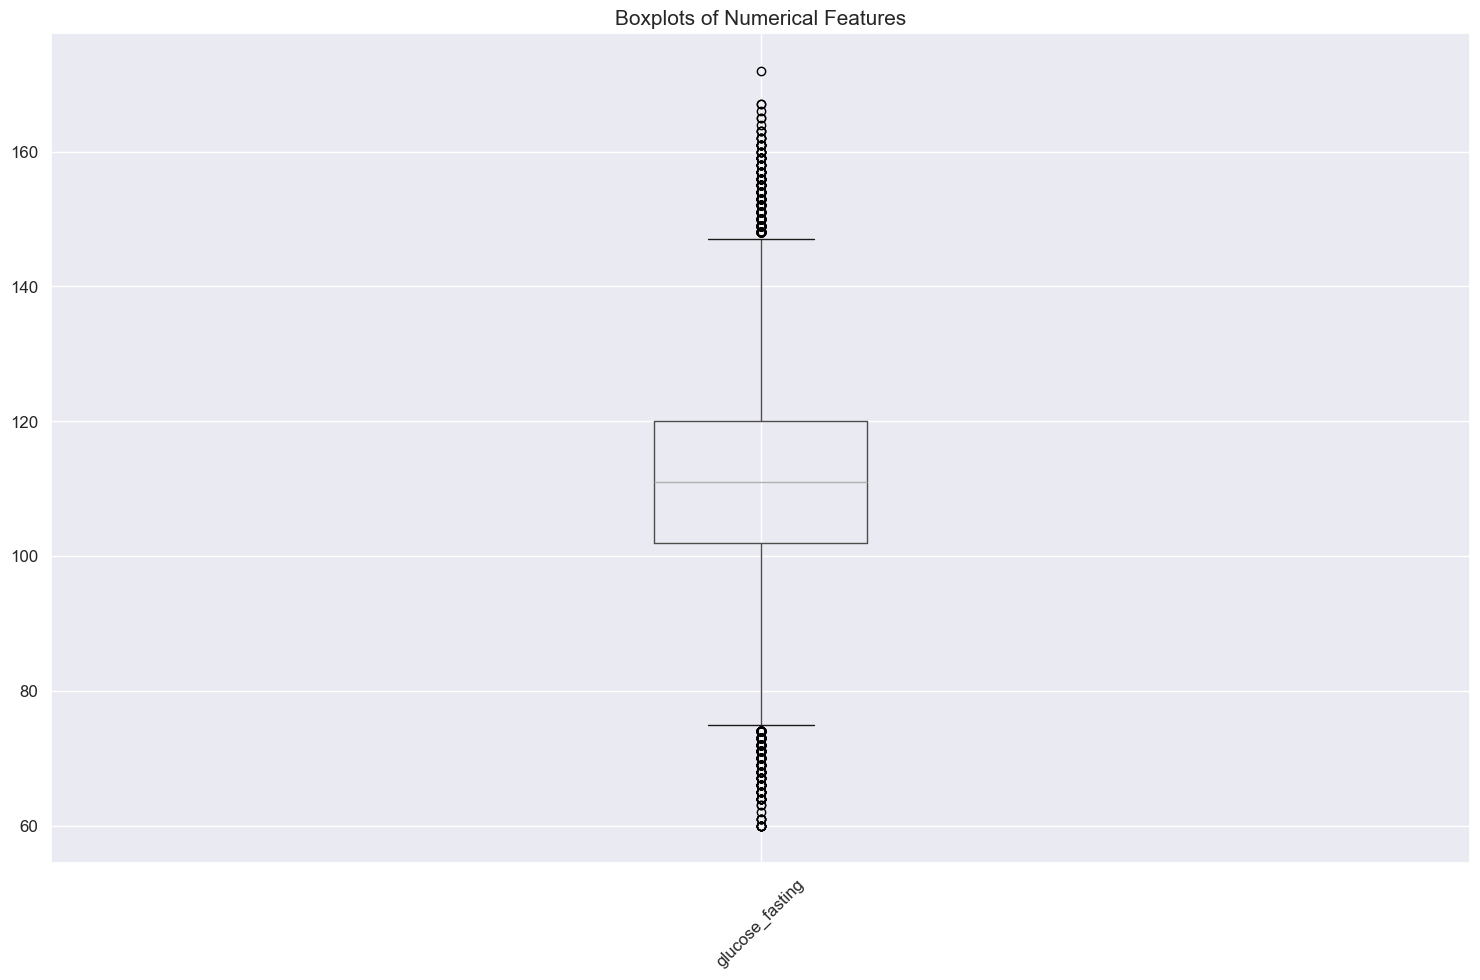

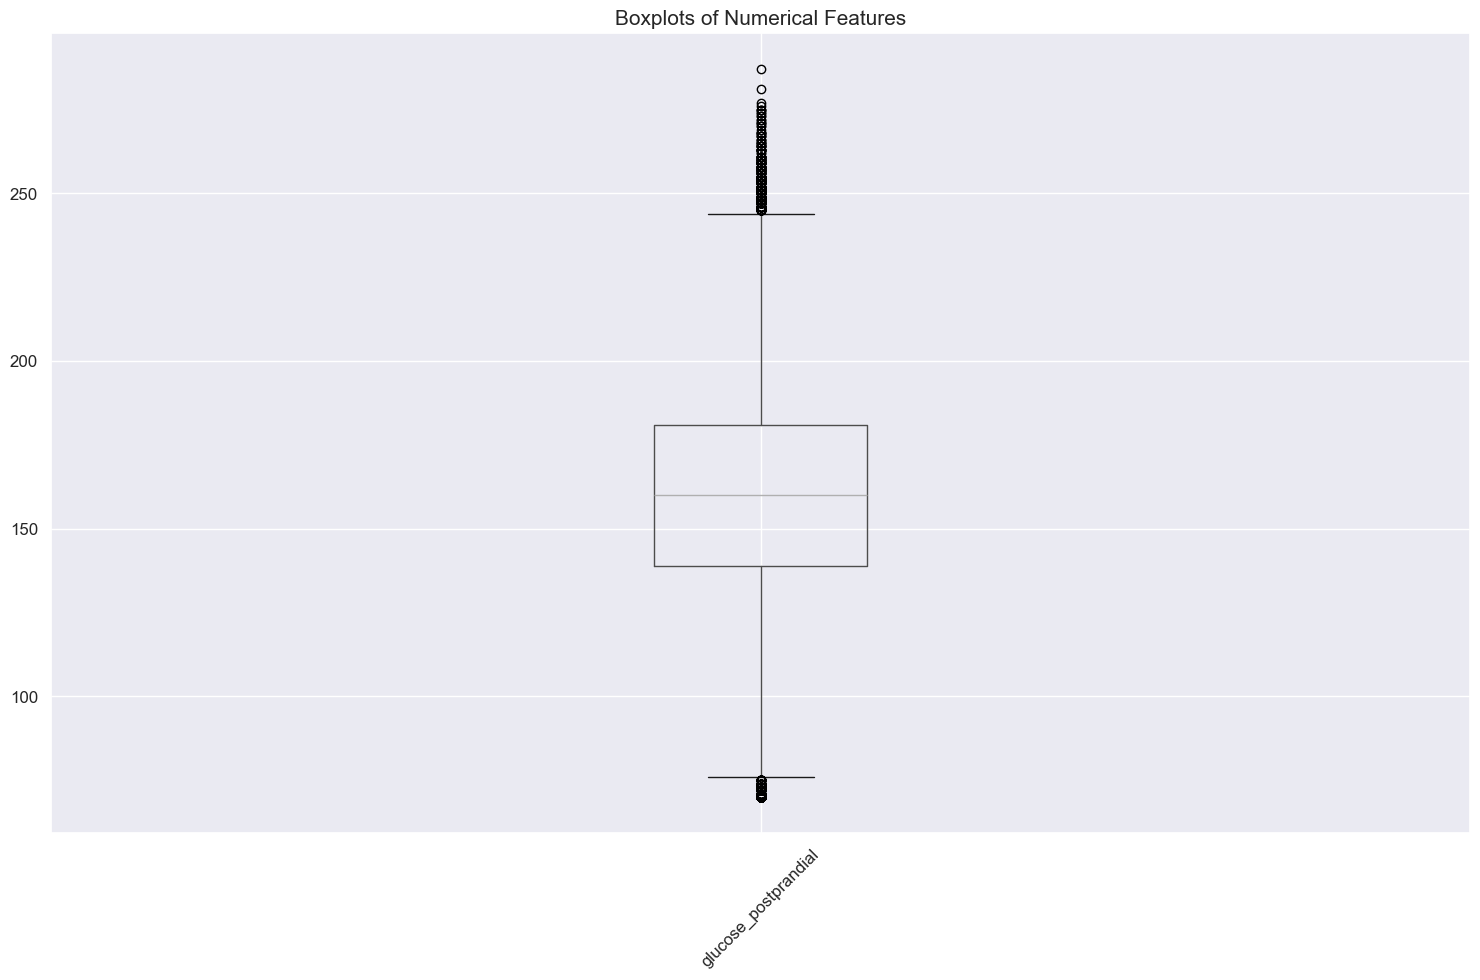

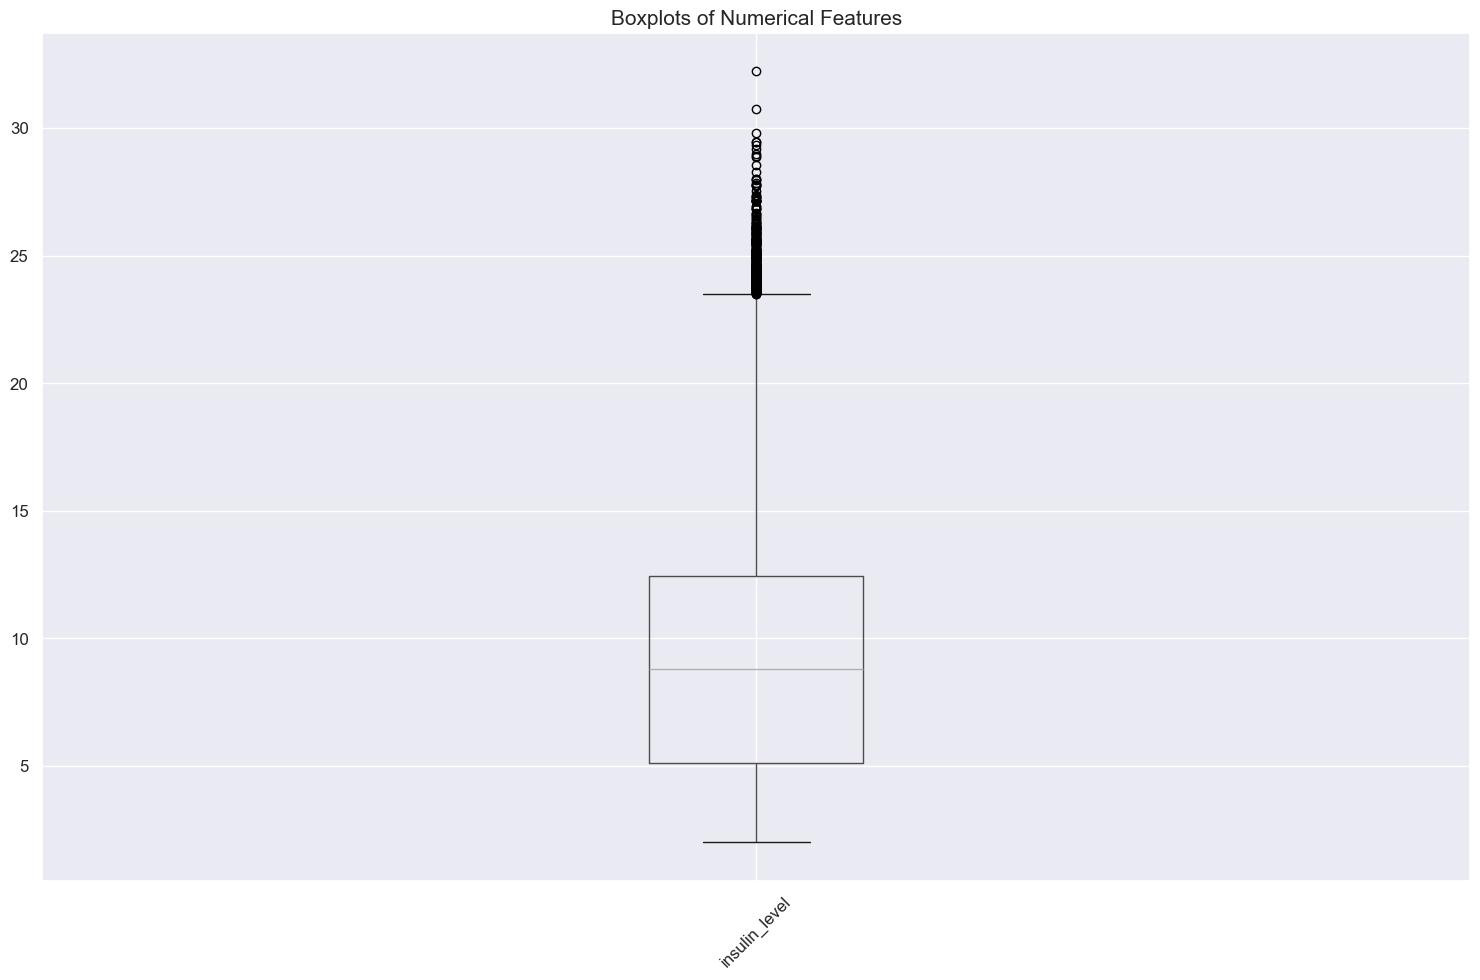

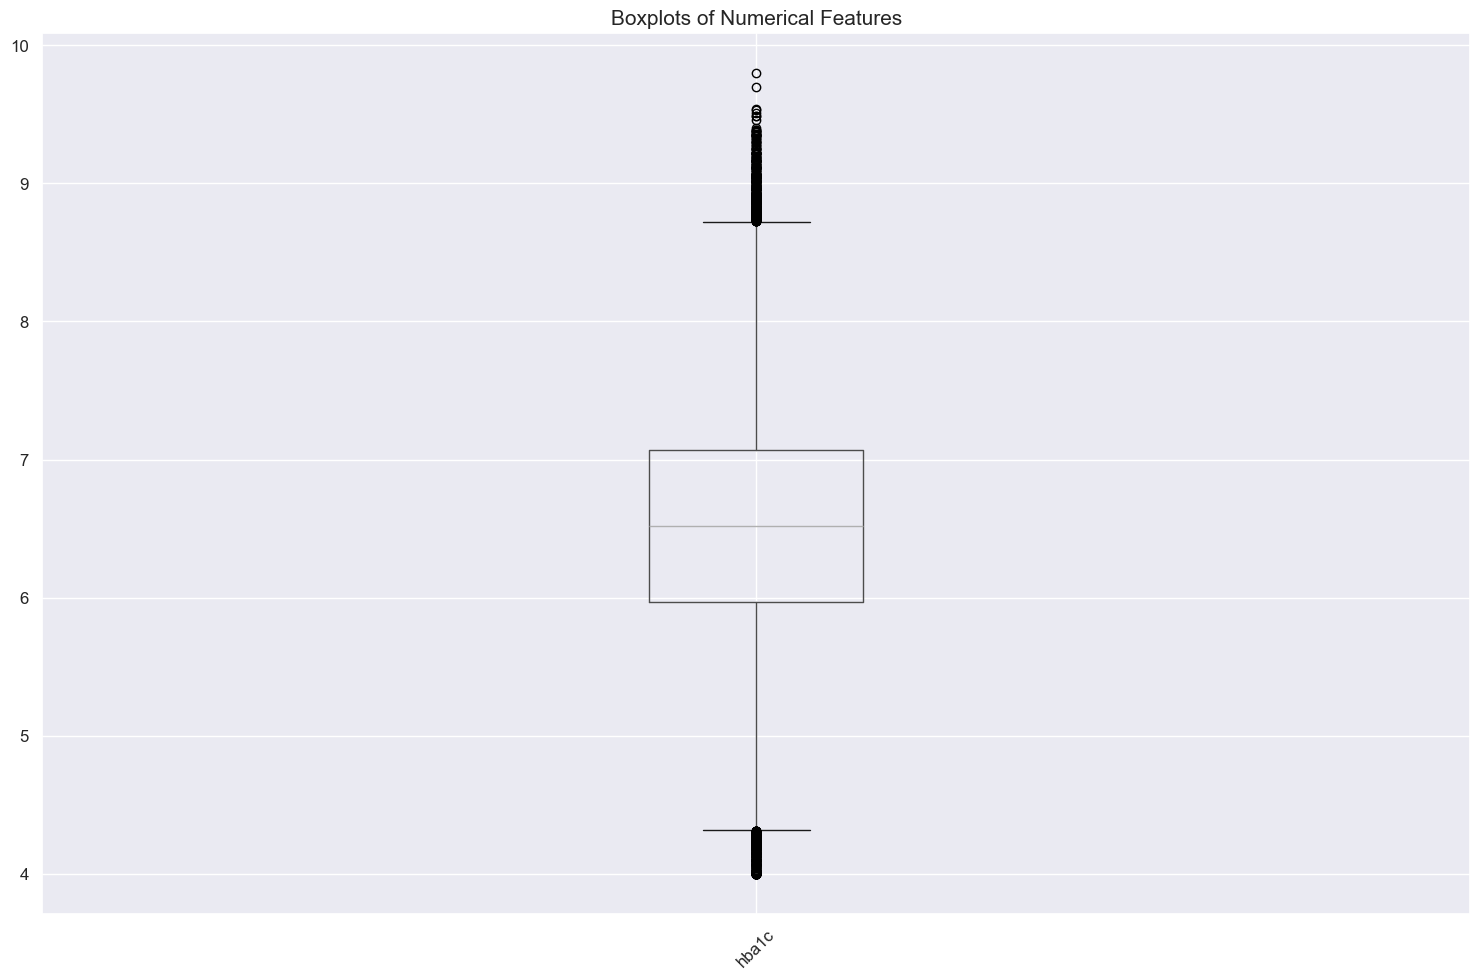

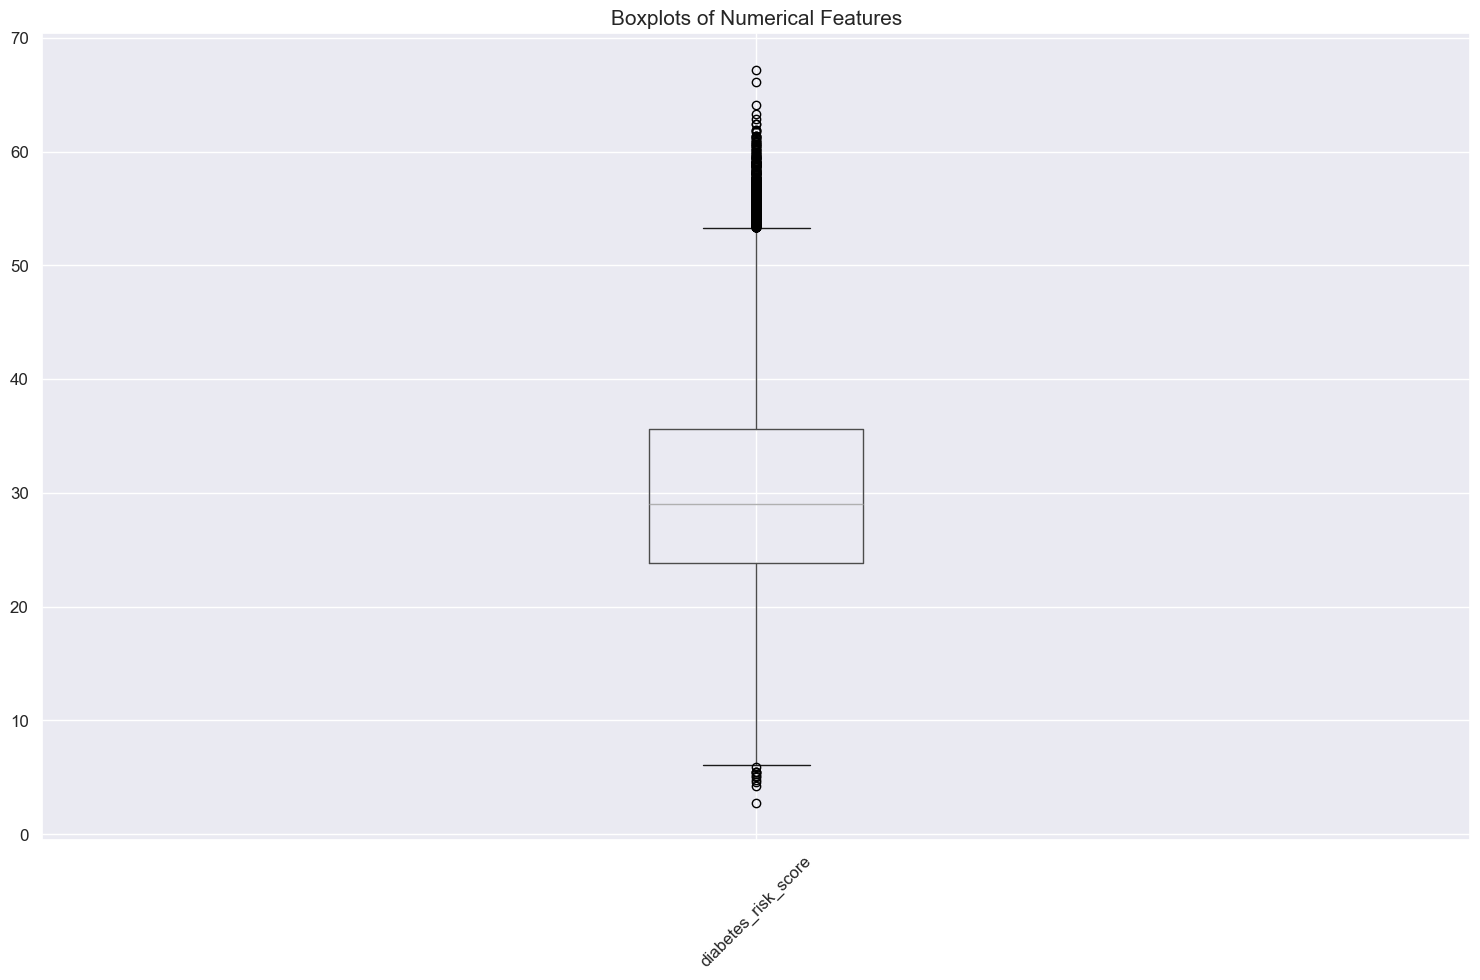

In [16]:
for col in numerical_cols:
    plt.figure(figsize=(15,10))
    df.boxplot(column=col)
    plt.title("Boxplots of Numerical Features", fontsize=15)
    plt.xticks(rotation = 45)
    plt.tight_layout()
    plt.show()

## Target Distribution and Class Imbalance

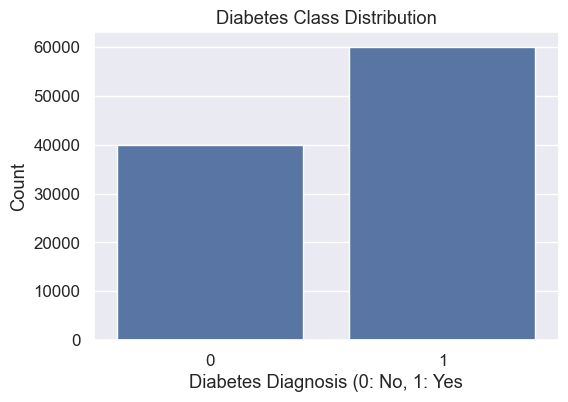

In [17]:
plt.figure(figsize=(6,4))
sns.countplot(x=df[target_col])
plt.title("Diabetes Class Distribution")
plt.xlabel("Diabetes Diagnosis (0: No, 1: Yes")
plt.ylabel("Count")
plt.show()

In [18]:
df[target_col].value_counts(normalize=True)

diagnosed_diabetes
1    0.59998
0    0.40002
Name: proportion, dtype: float64

## Categorical Feature Exploration

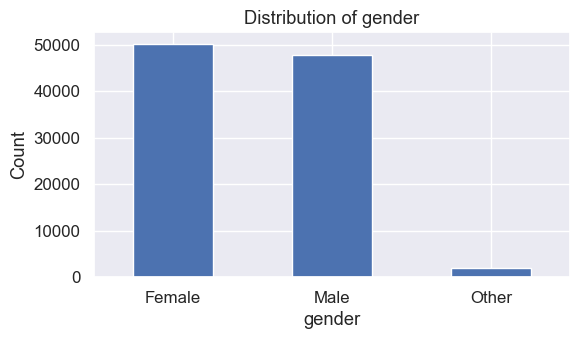

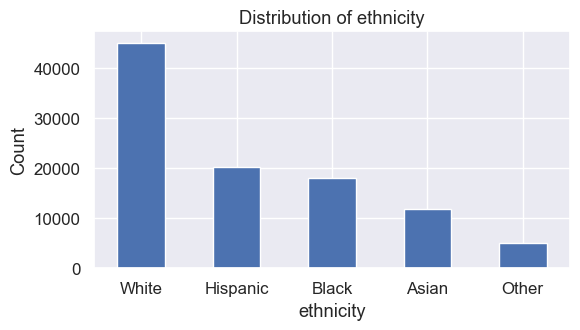

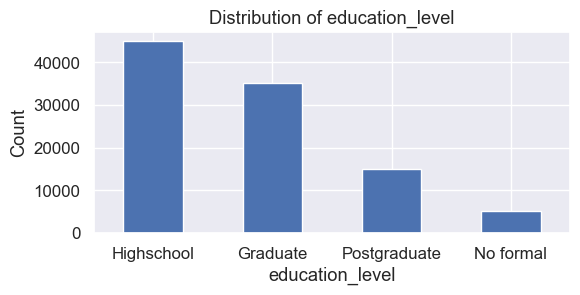

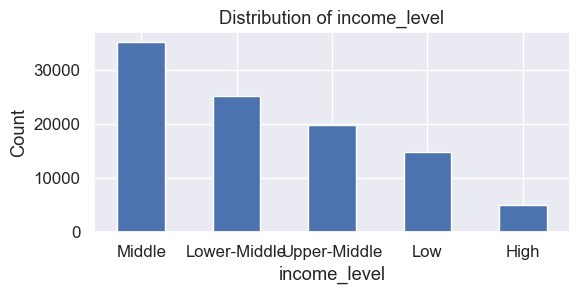

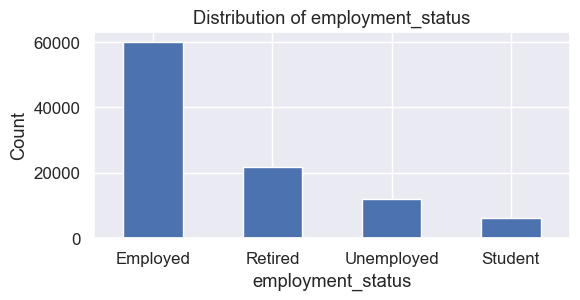

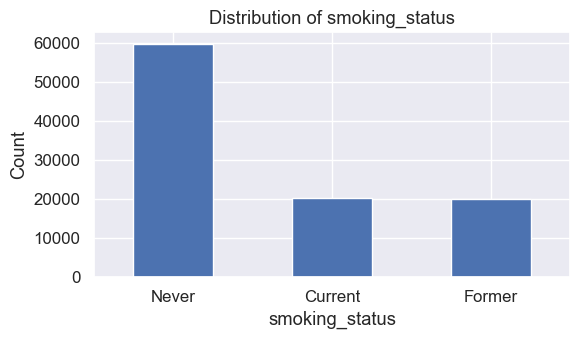

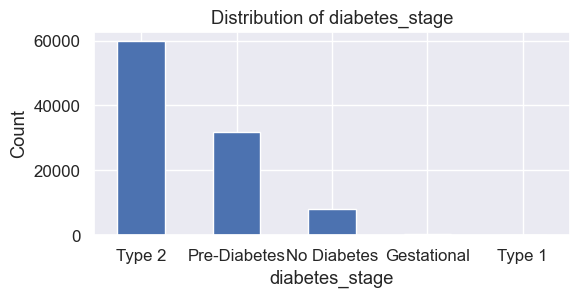

In [19]:
for c in categoriacal_cols:
    plt.figure(figsize=(6,4))
    df[c].value_counts().plot(kind='bar')
    plt.title(f"Distribution of {c}")
    plt.xlabel(c)
    plt.ylabel("Count")
    plt.tight_layout()
    plt.xticks(rotation=0)
    plt.show()

## Numeric Features versus Target

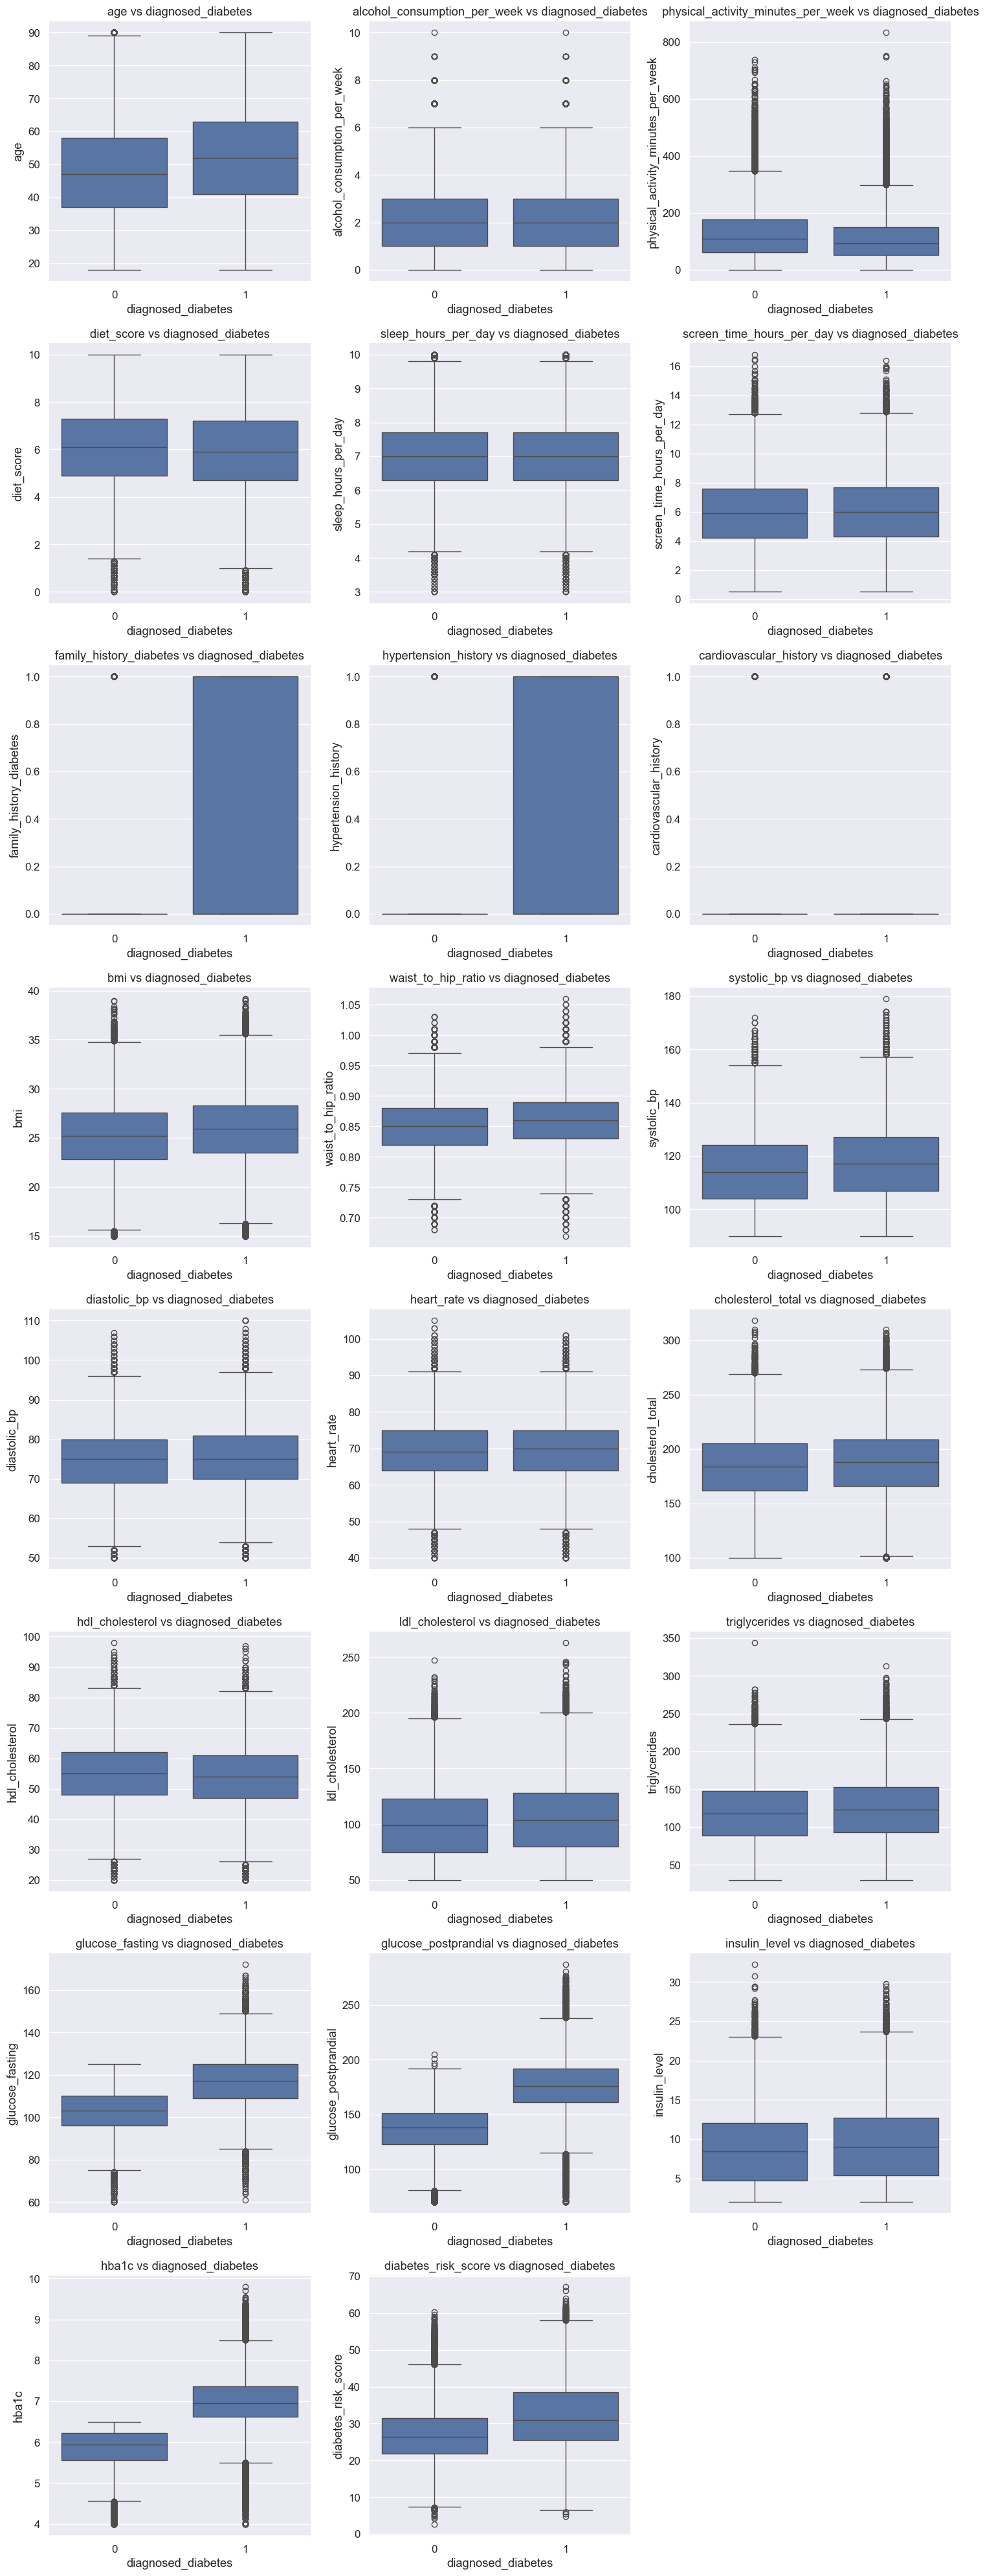

In [20]:
import math

n = len(numerical_cols)         
cols = 3                         
rows = math.ceil(n / cols)      

plt.figure(figsize=(15, 5*rows)) 

for i, col in enumerate(numerical_cols, 1):
    plt.subplot(rows, cols, i)
    sns.boxplot(x=df[target_col], y=df[col])
    plt.title(f"{col} vs {target_col}")

plt.tight_layout()
plt.show()

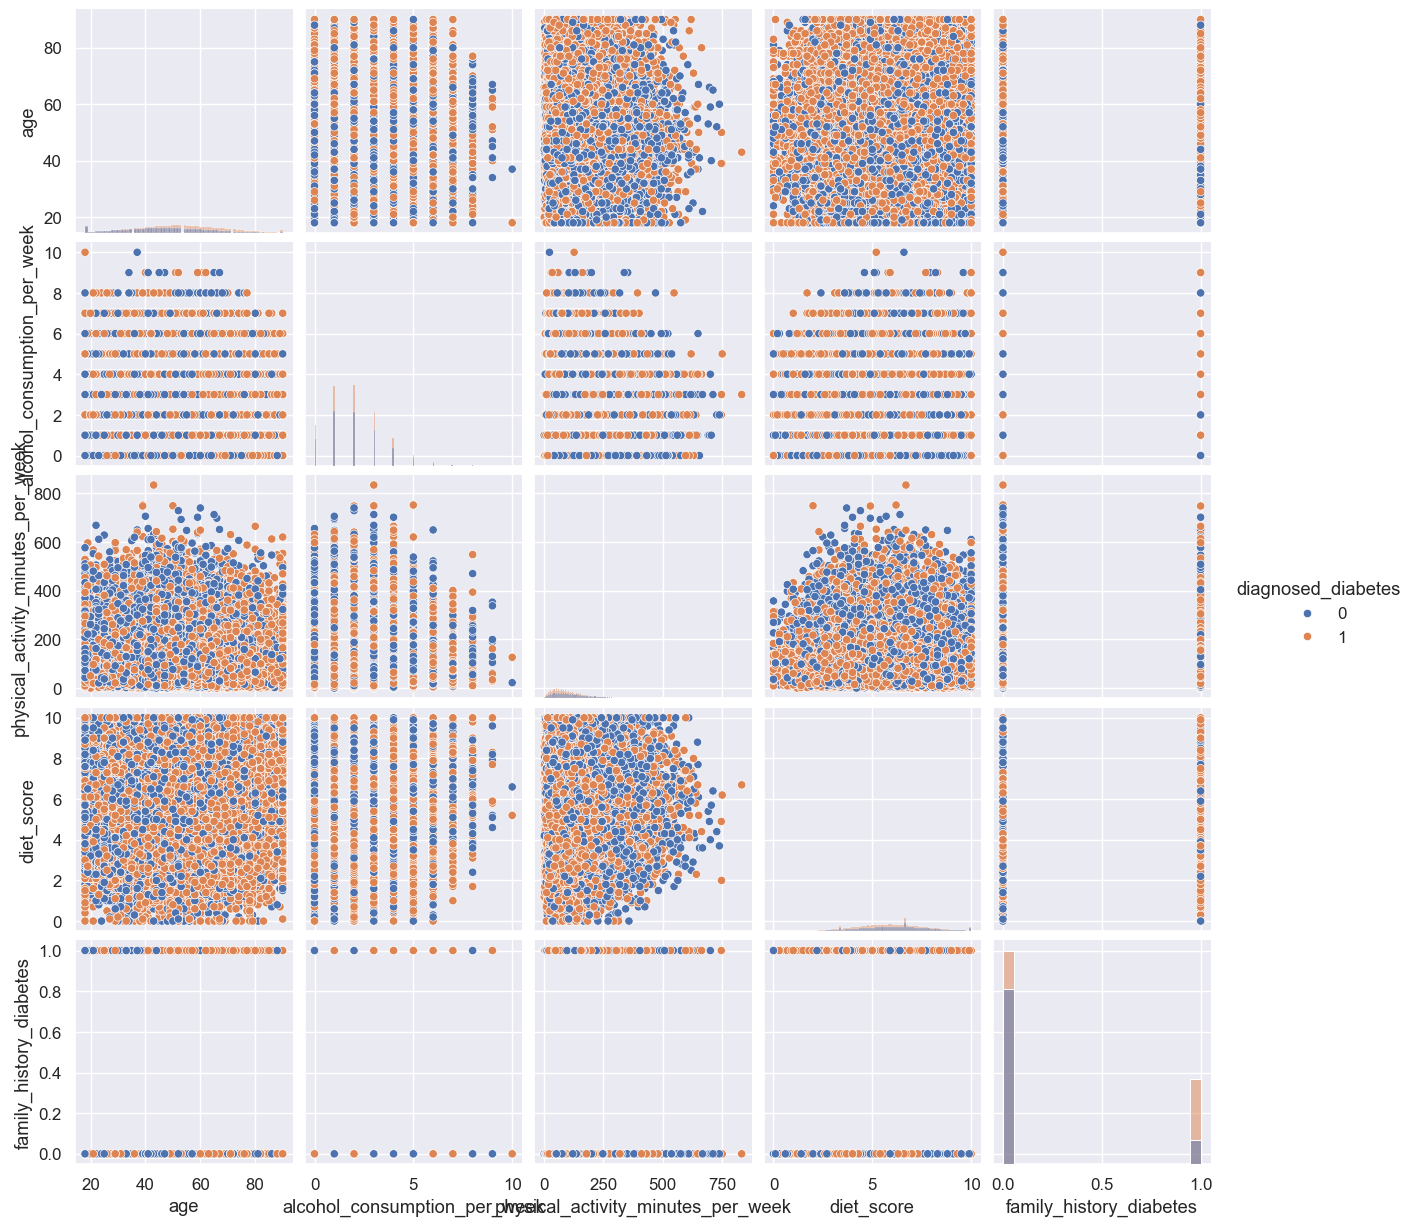

In [21]:
sns.pairplot(df[['age', 'alcohol_consumption_per_week', 'physical_activity_minutes_per_week', 'diet_score','family_history_diabetes','diagnosed_diabetes']], hue='diagnosed_diabetes', diag_kind='hist')
plt.show()

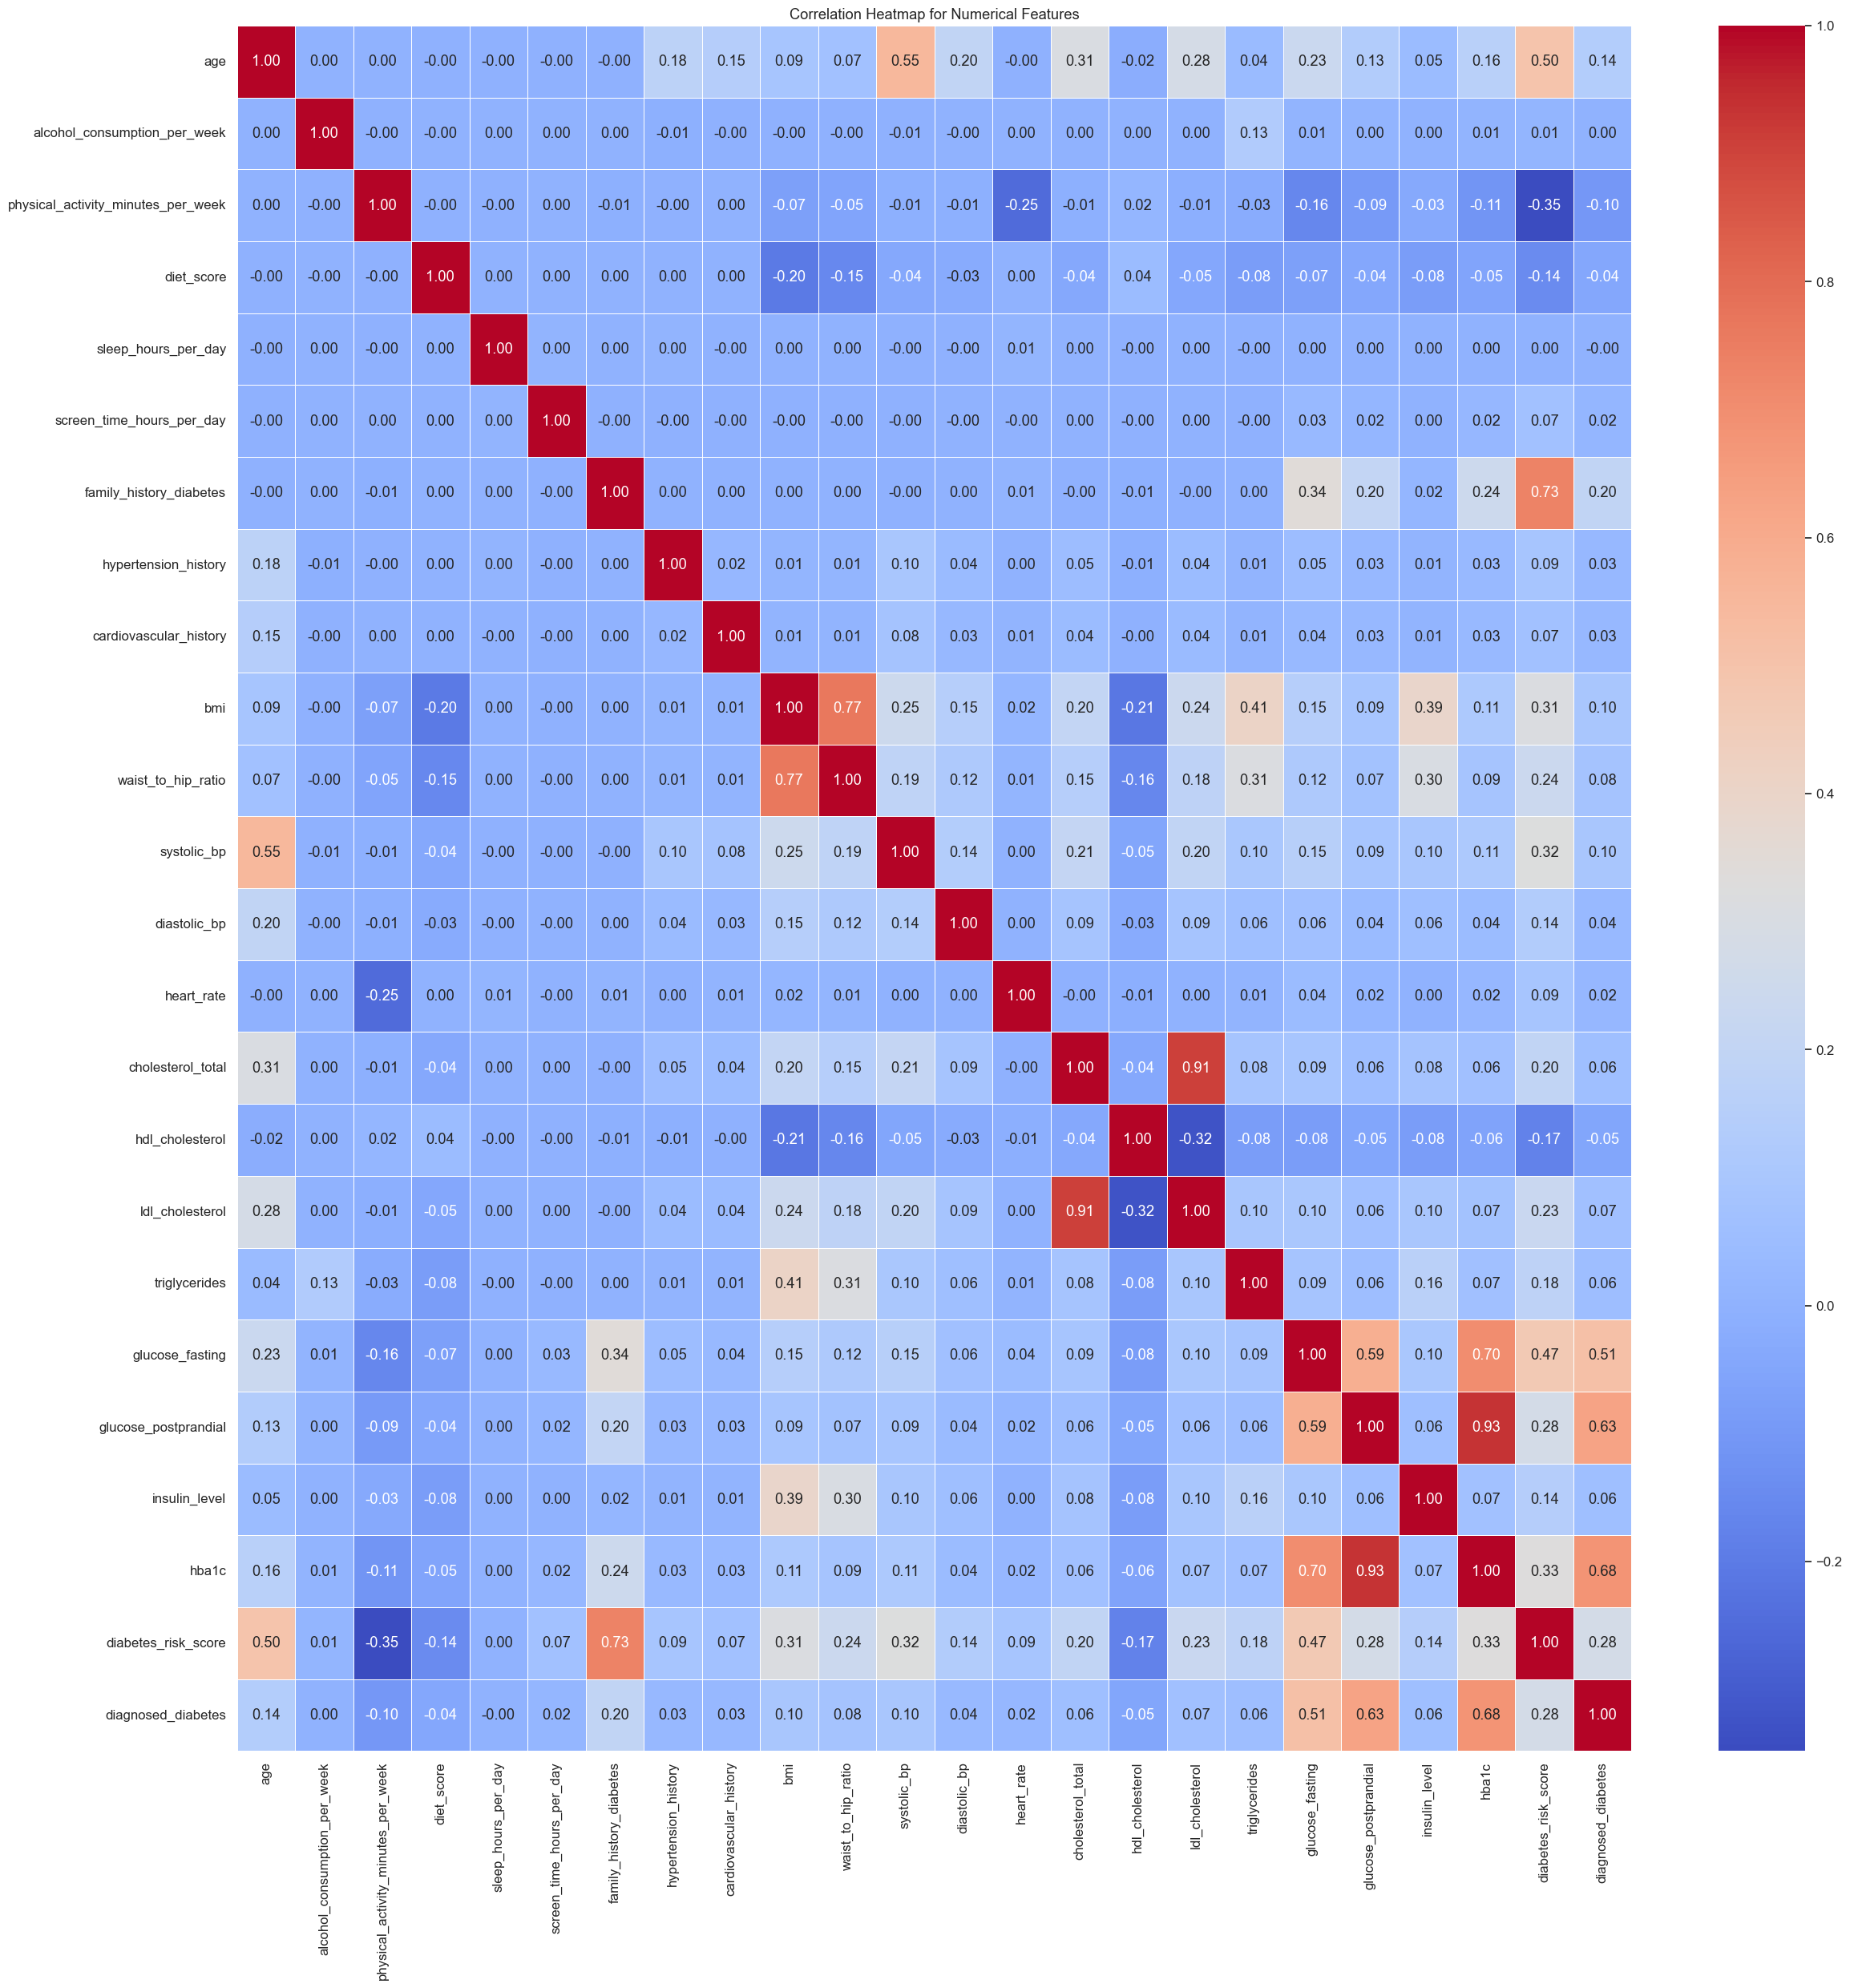

In [26]:
corr_matrix = df[numerical_cols + [target_col]].corr()
plt.figure(figsize=(25,25))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Heatmap for Numerical Features")
plt.tight_layout()
plt.show()

In [27]:
corr_matrix[target_col].sort_values(ascending=False)

diagnosed_diabetes                    1.000000
hba1c                                 0.679397
glucose_postprandial                  0.629832
glucose_fasting                       0.510919
diabetes_risk_score                   0.277300
family_history_diabetes               0.197926
age                                   0.137713
bmi                                   0.097057
systolic_bp                           0.095481
waist_to_hip_ratio                    0.078918
ldl_cholesterol                       0.067475
cholesterol_total                     0.058173
insulin_level                         0.057715
triglycerides                         0.056230
diastolic_bp                          0.035619
cardiovascular_history                0.029793
hypertension_history                  0.027524
heart_rate                            0.022785
screen_time_hours_per_day             0.018127
alcohol_consumption_per_week          0.000760
sleep_hours_per_day                  -0.000399
diet_score   

### Categorical Features versus Target


Proportion of Diabetes Diagnosis within gender:



diagnosed_diabetes,0,1
gender,,
Female,0.401545,0.598455
Male,0.399343,0.600657
Other,0.378043,0.621957


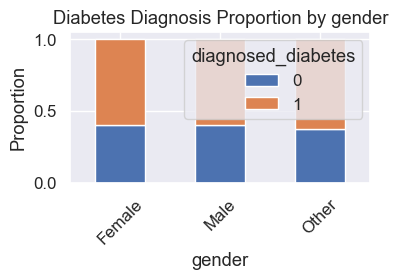


Proportion of Diabetes Diagnosis within ethnicity:



diagnosed_diabetes,0,1
ethnicity,,
Asian,0.399241,0.600759
Black,0.398588,0.601412
Hispanic,0.406059,0.593941
Other,0.392355,0.607645
White,0.398960,0.601040


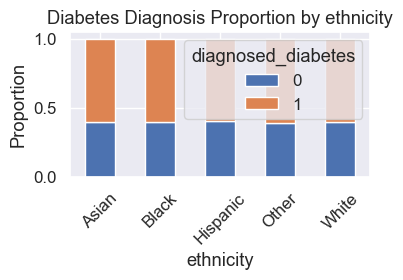


Proportion of Diabetes Diagnosis within education_level:



diagnosed_diabetes,0,1
education_level,,
Graduate,0.398807,0.601193
Highschool,0.399323,0.600677
No formal,0.395490,0.604510
Postgraduate,0.406492,0.593508


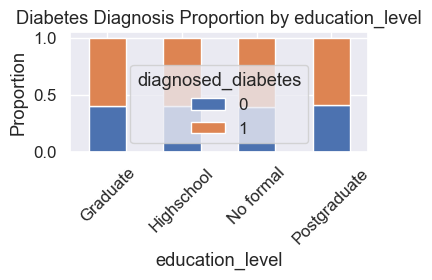


Proportion of Diabetes Diagnosis within income_level:



diagnosed_diabetes,0,1
income_level,,
High,0.392843,0.607157
Low,0.399461,0.600539
Lower-Middle,0.396143,0.603857
Middle,0.403306,0.596694
Upper-Middle,0.401339,0.598661


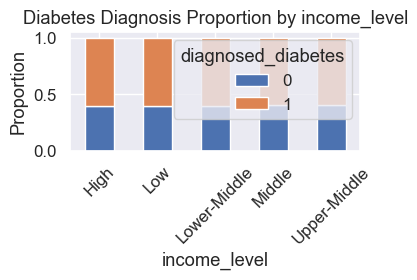


Proportion of Diabetes Diagnosis within employment_status:



diagnosed_diabetes,0,1
employment_status,,
Employed,0.398488,0.601512
Retired,0.404715,0.595285
Student,0.402701,0.597299
Unemployed,0.397802,0.602198


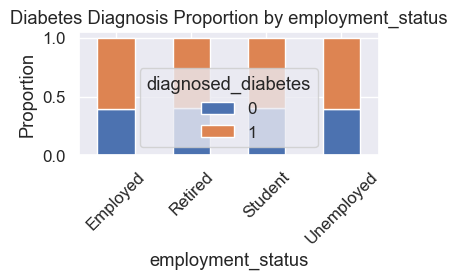


Proportion of Diabetes Diagnosis within smoking_status:



diagnosed_diabetes,0,1
smoking_status,,
Current,0.399931,0.600069
Former,0.398881,0.601119
Never,0.400431,0.599569


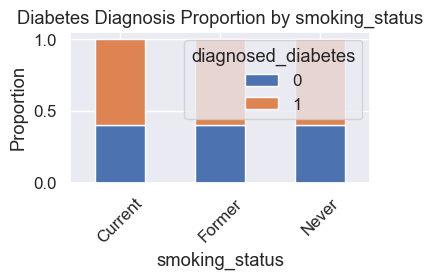


Proportion of Diabetes Diagnosis within diabetes_stage:



diagnosed_diabetes,0,1
diabetes_stage,,
Gestational,0.431655,0.568345
No Diabetes,1.000000,0.000000
Pre-Diabetes,1.000000,0.000000
Type 1,0.459016,0.540984
Type 2,0.000000,1.000000


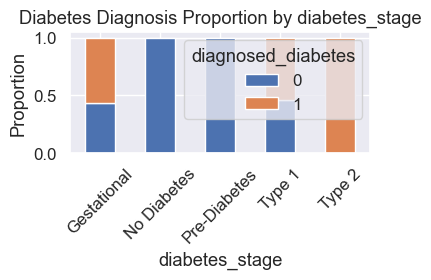

In [28]:
for col in categoriacal_cols:
    ct = pd.crosstab(df[col], df[target_col], normalize='index')
    print(f"\nProportion of Diabetes Diagnosis within {col}:\n")
    display(ct)
    
    ct.plot(kind='bar', stacked=True, figsize=(4,3))
    plt.title(f"Diabetes Diagnosis Proportion by {col}")
    plt.ylabel("Proportion")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
    